# STATISTIC ANALYSIS OF EXOPLANET TERMINATOR AND TRANSIT PHASES ASYMMETRY

    In this code below a project explicitly defined in files "Projekat_za_Nacionalnu Konferenciju_Astrostat" and "TRANSIT_WASP17B" is being done and analysed. In this Jupyter notebook version, everything is defined and done in first cell in meaning of creating spectral input for the rest of the code and analysis - per levels of asymmetries three transit phases (egress, mid-transit and egress), i. e. that part is now automatic as to eliminate human error in working with files. It saves those data in .txt files, and remaining metrics in .csv files. We started from ultra asymmetry as first model and configurational file that it uses for (which is the most extreme asymmetry, cloudfractions are 0, 50 and 100%, and same principle apllies to atmosphere temperatures), In future, a greater parameter grid will be added (other aerosols, etc).

In [1]:
# Needed imports for the notebook
import os
import re
from io import StringIO
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
import corner
from IPython.display import display

# Automatised generation of PSG spectra

This cell automatises:
- Asymmetry level varying,
- Sending `.cfg` files to NASA PSG system,
- Downloading `psg_rad.txt`,
- Renaming files pred:
  - asymmetry level,
  - Transit phase (`ingress`, `mid`, `egress`),
- Placing in aproppriate folders.

After executing this cell:
- The rest of the notebook works without change,
- Analysis, graphs and tables are generated automatically.


In [2]:
# ATMOSPHERE & GEOMETRY INTERPOLATION + PSG SPECTRUM & OBSERVER VIEW GENERATOR
PSG_URL = "https://psg.gsfc.nasa.gov/api.php"
OUTPUT_ROOT_DIR = "./output_results"
CFG_TEMPLATES = {"ingress": "Asym_1.0/wasp17b_transit_ingress_ultra_hazy_cold.cfg",
    "mid": "Asym_1.0/wasp17b_transit_mid_ultra_reference.cfg",
    "egress": "Asym_1.0/wasp17b_transit_egress_ultra_clear_hot.cfg"}
ASYM_PARAMS = ["TEMPERATURE", "CLOUDFRACTION", "AABUN"]
GEOMETRY_TAGS = ["<OBJECT-OFFSET-X>", "<OBJECT-OFFSET-Y>", "<OBJECT-STAR-DISTANCE>", "<GEOMETRY-PHASE>"]
def get_cfg_val(cfg_text, tag_name):
    res = re.search(rf"<{tag_name}>([-+0-9.eE]+)", cfg_text)
    return float(res.group(1)) if res else None
def set_cfg_val(cfg_text, tag_name, val_num):
    return re.sub(rf"<{tag_name}>[-+0-9.eE]+", f"<{tag_name}>{val_num}", cfg_text)
def apply_geometry(target_cfg, geo_source_cfg):
    """Copies physical observational geometry tags from source template."""
    out_cfg = target_cfg
    for g_tag in GEOMETRY_TAGS:
        t_name = g_tag.strip('<>')
        ref_val = get_cfg_val(geo_source_cfg, t_name)
        if ref_val is not None: out_cfg = set_cfg_val(out_cfg, t_name, ref_val)
    return out_cfg
def interpolate_atmosphere(ext_phase_cfg, mid_cfg, alpha_val, target_param):
    """
    Isolates target_param by locking all other atmospheric parameters/layers to baseline 
    mid_cfg values while inheriting phase-specific geometry from ext_phase_cfg.
    """
    out_cfg = apply_geometry(mid_cfg, ext_phase_cfg)
    for param in ["TEMPERATURE", "CLOUDFRACTION", "AABUN", "ASIZE"]:
        if param != target_param:
            m_val = get_cfg_val(mid_cfg, f"ATMOSPHERE-{param}")
            if m_val is not None: out_cfg = set_cfg_val(out_cfg, f"ATMOSPHERE-{param}", m_val)
            l_tag = f"ATMOSPHERE-LAYERS-{param}"
            m_layers_match = re.search(rf"<{l_tag}>([0-9.,\-+eE\s]+)", mid_cfg)
            if m_layers_match: out_cfg = re.sub(rf"<{l_tag}>[0-9.,\-+eE\s]+", f"<{l_tag}>{m_layers_match.group(1)}", out_cfg)
    t_tag = f"ATMOSPHERE-{target_param}"
    l_tag = f"ATMOSPHERE-LAYERS-{target_param}"
    m_val = get_cfg_val(mid_cfg, t_tag)
    e_val = get_cfg_val(ext_phase_cfg, t_tag)
    if m_val is not None and e_val is not None:
        out_cfg = set_cfg_val(out_cfg, t_tag, m_val + alpha_val * (e_val - m_val))
    m_layers_match = re.search(rf"<{l_tag}>([0-9.,\-+eE\s]+)", mid_cfg)
    e_layers_match = re.search(rf"<{l_tag}>([0-9.,\-+eE\s]+)", ext_phase_cfg)
    if m_layers_match and e_layers_match:
        m_arr = np.array([float(x) for x in m_layers_match.group(1).replace(' ', '').split(',')])
        e_arr = np.array([float(x) for x in e_layers_match.group(1).replace(' ', '').split(',')])
        arr_str = ",".join([f"{x:.6g}" for x in (m_arr + alpha_val * (e_arr - m_arr))])
        out_cfg = re.sub(rf"<{l_tag}>[0-9.,\-+eE\s]+", f"<{l_tag}>{arr_str}", out_cfg)
    return out_cfg
def fetch_psg_spectrum_and_view(cfg_text, txt_path, img_path):
    resp_spec = requests.post(PSG_URL, data=cfg_text.encode("utf-8"), 
                              headers={"User-Agent": "Mozilla/5.0", "Content-Type": "text/plain"}, timeout=300)
    if resp_spec.status_code == 200 and ("# Wave/freq" in resp_spec.text or "#Wave/freq" in resp_spec.text):
        with open(txt_path, "w", encoding="utf-8") as f:
            f.write(resp_spec.text)
    else:
        print(f"Error fetching spectrum for {txt_path}")
    resp_view = requests.post(PSG_URL, data={'file': cfg_text, 'type': 'view'}, timeout=60)
    if resp_view.status_code == 200 and len(resp_view.content) > 100:
        with open(img_path, "wb") as f:
            f.write(resp_view.content)
def run_asymmetry_pipeline():
    with open(CFG_TEMPLATES["ingress"], "r", encoding="utf-8") as f: cfg_ing_base = f.read()
    with open(CFG_TEMPLATES["mid"], "r", encoding="utf-8") as f: cfg_mid = f.read()
    with open(CFG_TEMPLATES["egress"], "r", encoding="utf-8") as f: cfg_eg_base = f.read()
    total_runs = 0
    # Generates exact array: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    alpha_levels = [round(a, 1) for a in np.linspace(0.1, 1.0, 10)]
    for p_mode in ASYM_PARAMS:
        print(f"\n--- RUNNING ISOLATION SWEEP: Param_{p_mode} ---")
        for alpha in alpha_levels:
            asym_dir = os.path.join(OUTPUT_ROOT_DIR, f"Param_{p_mode}_Asym_{alpha:.1f}")
            os.makedirs(asym_dir, exist_ok=True)
            ing_cfg = interpolate_atmosphere(cfg_ing_base, cfg_mid, alpha, p_mode)
            eg_cfg = interpolate_atmosphere(cfg_eg_base, cfg_mid, alpha, p_mode)
            scenarios = {"ingress": ing_cfg, "mid": cfg_mid, "egress": eg_cfg}
            for phase_key, scenario_cfg in scenarios.items():
                cfg_path = os.path.join(asym_dir, f"{phase_key}.cfg")
                txt_path = os.path.join(asym_dir, f"{phase_key}.txt")
                img_path = os.path.join(asym_dir, f"{phase_key}_view.png")
                with open(cfg_path, "w", encoding="utf-8") as f:
                    f.write(scenario_cfg)
                fetch_psg_spectrum_and_view(scenario_cfg, txt_path, img_path)
                total_runs += 1 
            print(f" Done α = {alpha:.1f} -> Generated spectra & views for {p_mode}")   
    print(f"\nPIPELINE COMPLETE. Total generated phase runs: {total_runs}")
run_asymmetry_pipeline()


--- RUNNING ISOLATION SWEEP: Param_TEMPERATURE ---
 Done α = 0.1 -> Generated spectra & views for TEMPERATURE
 Done α = 0.2 -> Generated spectra & views for TEMPERATURE
 Done α = 0.3 -> Generated spectra & views for TEMPERATURE
 Done α = 0.4 -> Generated spectra & views for TEMPERATURE
 Done α = 0.5 -> Generated spectra & views for TEMPERATURE
 Done α = 0.6 -> Generated spectra & views for TEMPERATURE
 Done α = 0.7 -> Generated spectra & views for TEMPERATURE
 Done α = 0.8 -> Generated spectra & views for TEMPERATURE
 Done α = 0.9 -> Generated spectra & views for TEMPERATURE
 Done α = 1.0 -> Generated spectra & views for TEMPERATURE

--- RUNNING ISOLATION SWEEP: Param_CLOUDFRACTION ---
 Done α = 0.1 -> Generated spectra & views for CLOUDFRACTION
 Done α = 0.2 -> Generated spectra & views for CLOUDFRACTION
 Done α = 0.3 -> Generated spectra & views for CLOUDFRACTION
 Done α = 0.4 -> Generated spectra & views for CLOUDFRACTION
 Done α = 0.5 -> Generated spectra & views for CLOUDFRACTION

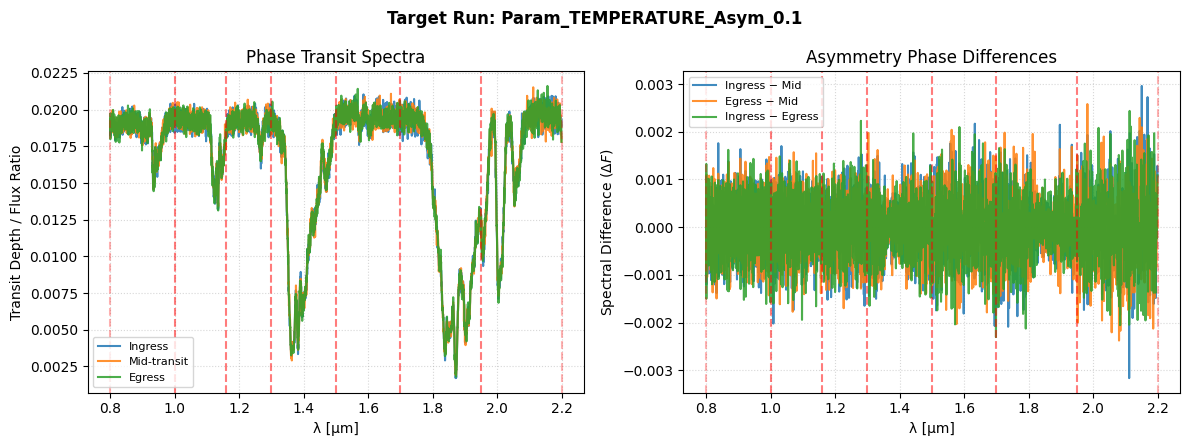

 REGIONAL METRICS FOR: Param_TEMPERATURE_Asym_0.1


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,-0.000053,0.037156,0.000422,0.000012,5.937167,0.854985
1,1.00-1.16,-0.000564,0.047765,0.000438,0.000015,4.349557,0.945598
2,1.16-1.30,0.000026,0.054305,0.000469,0.000019,6.196017,0.589538
3,1.30-1.50,-0.002483,0.049055,0.000400,0.000015,3.296297,0.995069
4,1.50-1.70,-0.001018,0.052715,0.000542,0.000022,5.816045,0.271913
5,1.70-1.95,0.000463,0.049735,0.000456,0.000017,3.142635,0.995258
6,1.95-2.20,-0.000754,0.052865,0.000600,0.000026,4.020994,0.976524



GLOBAL METRICS FOR: Param_TEMPERATURE_Asym_0.1


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_TEMPERATURE_Asym_0.1,0.000595,0.000008,-0.000094,0.002581


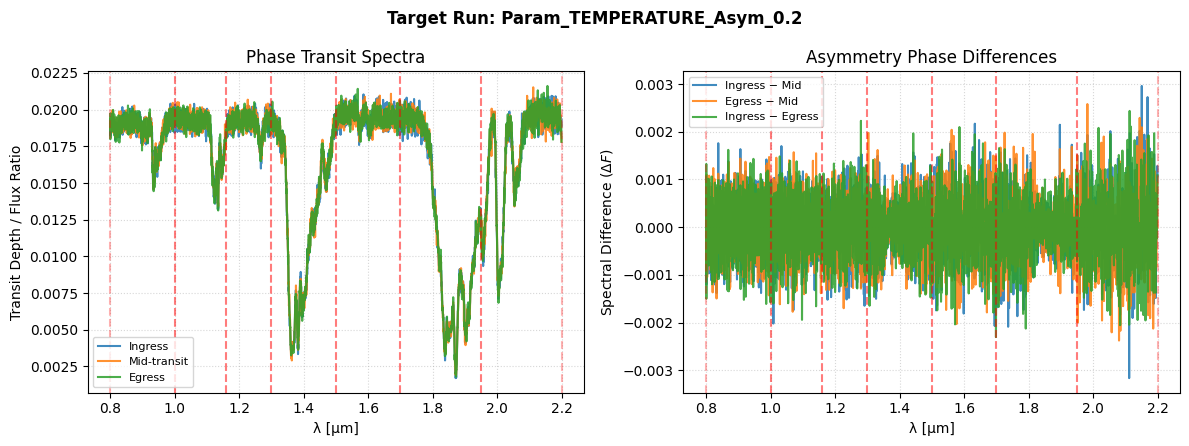

 REGIONAL METRICS FOR: Param_TEMPERATURE_Asym_0.2


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,-0.000053,0.037156,0.000422,0.000012,5.937167,0.854985
1,1.00-1.16,-0.000564,0.047765,0.000438,0.000015,4.349557,0.945598
2,1.16-1.30,0.000026,0.054305,0.000469,0.000019,6.196017,0.589538
3,1.30-1.50,-0.002483,0.049055,0.000400,0.000015,3.296297,0.995069
4,1.50-1.70,-0.001018,0.052715,0.000542,0.000022,5.816045,0.271913
5,1.70-1.95,0.000463,0.049735,0.000456,0.000017,3.142635,0.995258
6,1.95-2.20,-0.000754,0.052865,0.000600,0.000026,4.020994,0.976524



GLOBAL METRICS FOR: Param_TEMPERATURE_Asym_0.2


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_TEMPERATURE_Asym_0.2,0.000595,0.000008,-0.000094,0.002581


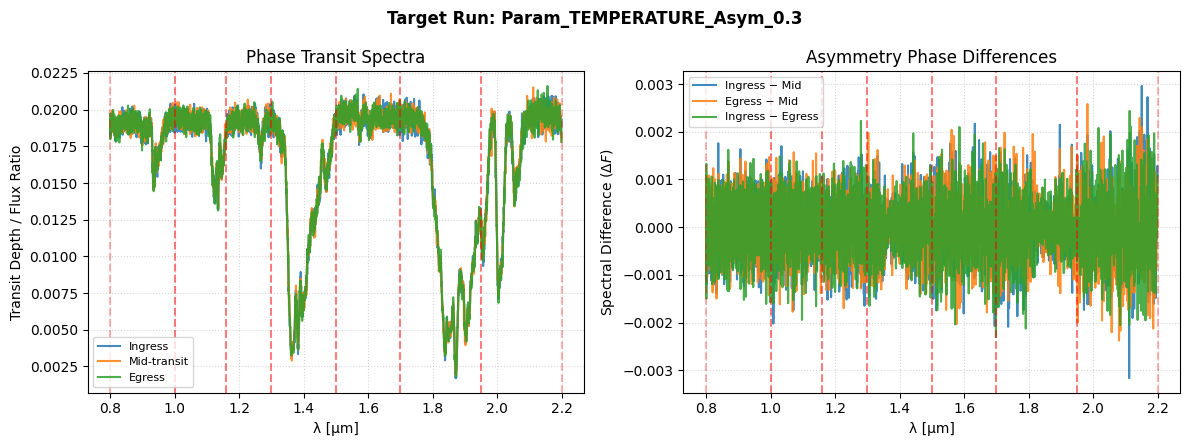

 REGIONAL METRICS FOR: Param_TEMPERATURE_Asym_0.3


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,-0.000053,0.037156,0.000422,0.000012,5.937167,0.854985
1,1.00-1.16,-0.000564,0.047765,0.000438,0.000015,4.349557,0.945598
2,1.16-1.30,0.000026,0.054305,0.000469,0.000019,6.196017,0.589538
3,1.30-1.50,-0.002483,0.049055,0.000400,0.000015,3.296297,0.995069
4,1.50-1.70,-0.001018,0.052715,0.000542,0.000022,5.816045,0.271913
5,1.70-1.95,0.000463,0.049735,0.000456,0.000017,3.142635,0.995258
6,1.95-2.20,-0.000754,0.052865,0.000600,0.000026,4.020994,0.976524



GLOBAL METRICS FOR: Param_TEMPERATURE_Asym_0.3


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_TEMPERATURE_Asym_0.3,0.000595,0.000008,-0.000094,0.002581


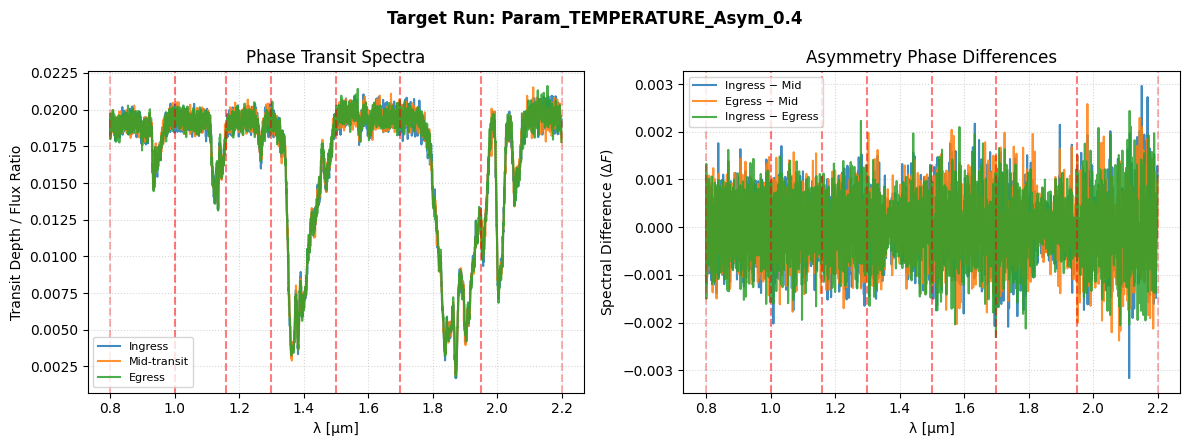

 REGIONAL METRICS FOR: Param_TEMPERATURE_Asym_0.4


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,-0.000053,0.037156,0.000422,0.000012,5.937167,0.854985
1,1.00-1.16,-0.000564,0.047765,0.000438,0.000015,4.349557,0.945598
2,1.16-1.30,0.000026,0.054305,0.000469,0.000019,6.196017,0.589538
3,1.30-1.50,-0.002483,0.049055,0.000400,0.000015,3.296297,0.995069
4,1.50-1.70,-0.001018,0.052715,0.000542,0.000022,5.816045,0.271913
5,1.70-1.95,0.000463,0.049735,0.000456,0.000017,3.142635,0.995258
6,1.95-2.20,-0.000754,0.052865,0.000600,0.000026,4.020994,0.976524



GLOBAL METRICS FOR: Param_TEMPERATURE_Asym_0.4


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_TEMPERATURE_Asym_0.4,0.000595,0.000008,-0.000094,0.002581


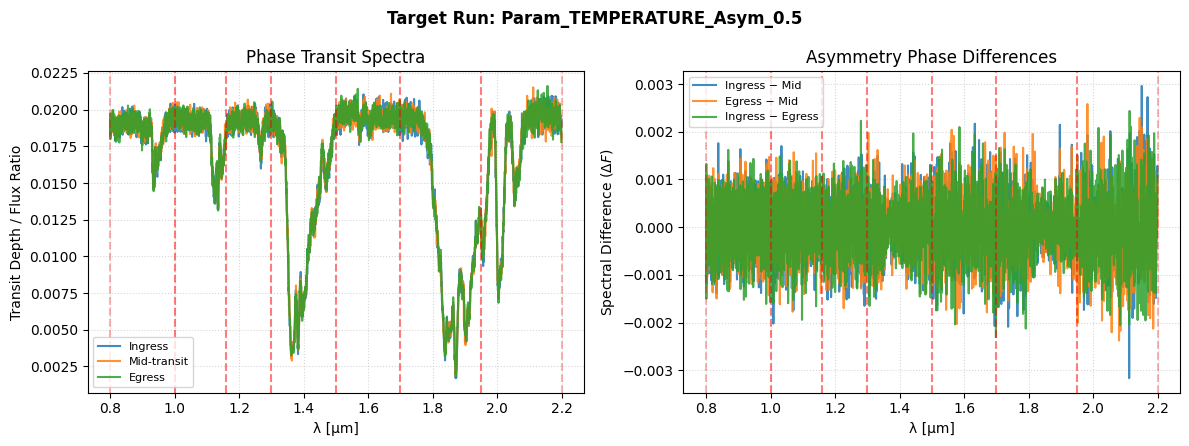

 REGIONAL METRICS FOR: Param_TEMPERATURE_Asym_0.5


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,-0.000053,0.037156,0.000422,0.000012,5.937167,0.854985
1,1.00-1.16,-0.000564,0.047765,0.000438,0.000015,4.349557,0.945598
2,1.16-1.30,0.000026,0.054305,0.000469,0.000019,6.196017,0.589538
3,1.30-1.50,-0.002483,0.049055,0.000400,0.000015,3.296297,0.995069
4,1.50-1.70,-0.001018,0.052715,0.000542,0.000022,5.816045,0.271913
5,1.70-1.95,0.000463,0.049735,0.000456,0.000017,3.142635,0.995258
6,1.95-2.20,-0.000754,0.052865,0.000600,0.000026,4.020994,0.976524



GLOBAL METRICS FOR: Param_TEMPERATURE_Asym_0.5


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_TEMPERATURE_Asym_0.5,0.000595,0.000008,-0.000094,0.002581


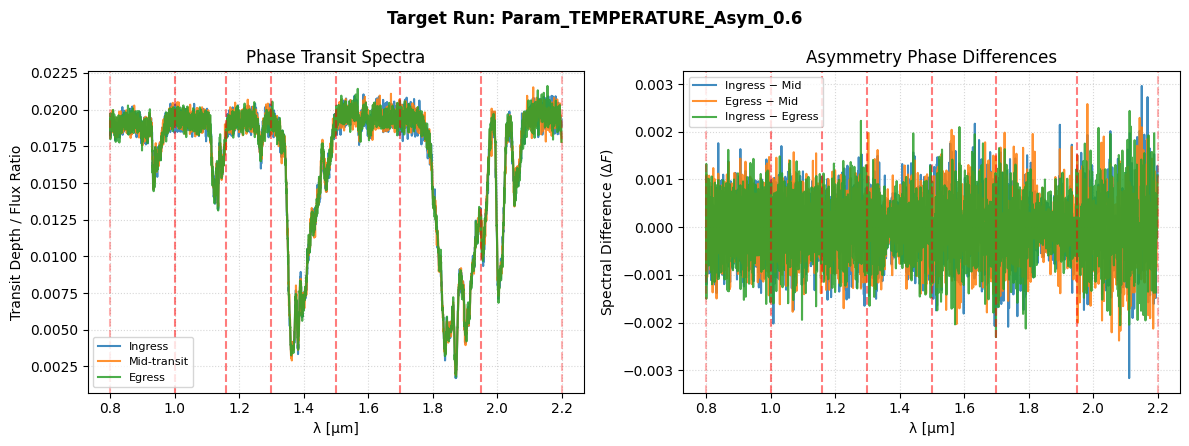

 REGIONAL METRICS FOR: Param_TEMPERATURE_Asym_0.6


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,-0.000053,0.037156,0.000422,0.000012,5.937167,0.854985
1,1.00-1.16,-0.000564,0.047765,0.000438,0.000015,4.349557,0.945598
2,1.16-1.30,0.000026,0.054305,0.000469,0.000019,6.196017,0.589538
3,1.30-1.50,-0.002483,0.049055,0.000400,0.000015,3.296297,0.995069
4,1.50-1.70,-0.001018,0.052715,0.000542,0.000022,5.816045,0.271913
5,1.70-1.95,0.000463,0.049735,0.000456,0.000017,3.142635,0.995258
6,1.95-2.20,-0.000754,0.052865,0.000600,0.000026,4.020994,0.976524



GLOBAL METRICS FOR: Param_TEMPERATURE_Asym_0.6


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_TEMPERATURE_Asym_0.6,0.000595,0.000008,-0.000094,0.002581


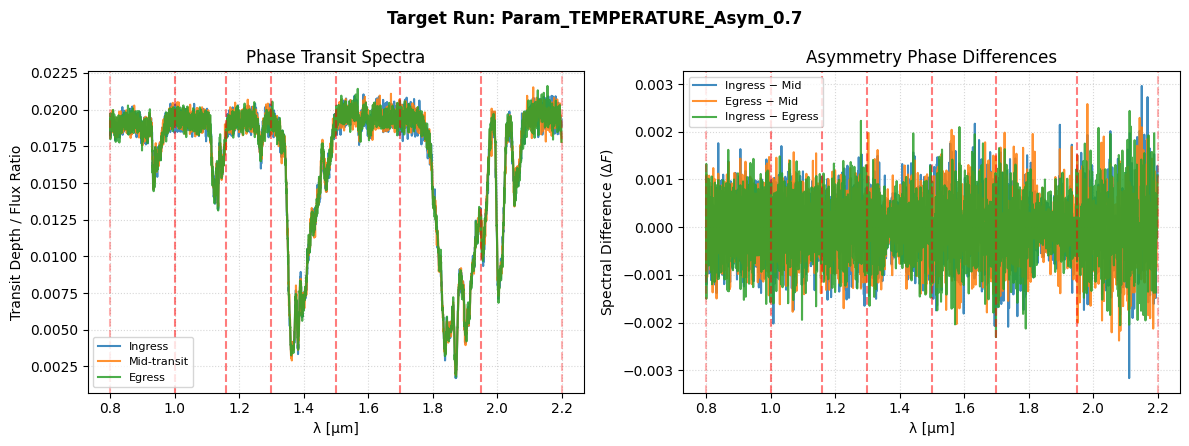

 REGIONAL METRICS FOR: Param_TEMPERATURE_Asym_0.7


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,-0.000053,0.037156,0.000422,0.000012,5.937167,0.854985
1,1.00-1.16,-0.000564,0.047765,0.000438,0.000015,4.349557,0.945598
2,1.16-1.30,0.000026,0.054305,0.000469,0.000019,6.196017,0.589538
3,1.30-1.50,-0.002483,0.049055,0.000400,0.000015,3.296297,0.995069
4,1.50-1.70,-0.001018,0.052715,0.000542,0.000022,5.816045,0.271913
5,1.70-1.95,0.000463,0.049735,0.000456,0.000017,3.142635,0.995258
6,1.95-2.20,-0.000754,0.052865,0.000600,0.000026,4.020994,0.976524



GLOBAL METRICS FOR: Param_TEMPERATURE_Asym_0.7


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_TEMPERATURE_Asym_0.7,0.000595,0.000008,-0.000094,0.002581


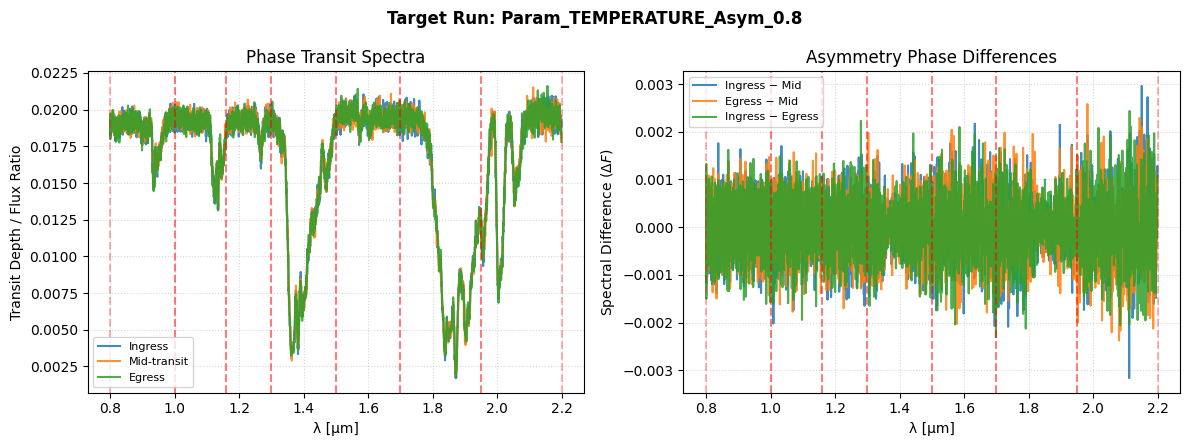

 REGIONAL METRICS FOR: Param_TEMPERATURE_Asym_0.8


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,-0.000053,0.037156,0.000422,0.000012,5.937167,0.854985
1,1.00-1.16,-0.000564,0.047765,0.000438,0.000015,4.349557,0.945598
2,1.16-1.30,0.000026,0.054305,0.000469,0.000019,6.196017,0.589538
3,1.30-1.50,-0.002483,0.049055,0.000400,0.000015,3.296297,0.995069
4,1.50-1.70,-0.001018,0.052715,0.000542,0.000022,5.816045,0.271913
5,1.70-1.95,0.000463,0.049735,0.000456,0.000017,3.142635,0.995258
6,1.95-2.20,-0.000754,0.052865,0.000600,0.000026,4.020994,0.976524



GLOBAL METRICS FOR: Param_TEMPERATURE_Asym_0.8


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_TEMPERATURE_Asym_0.8,0.000595,0.000008,-0.000094,0.002581


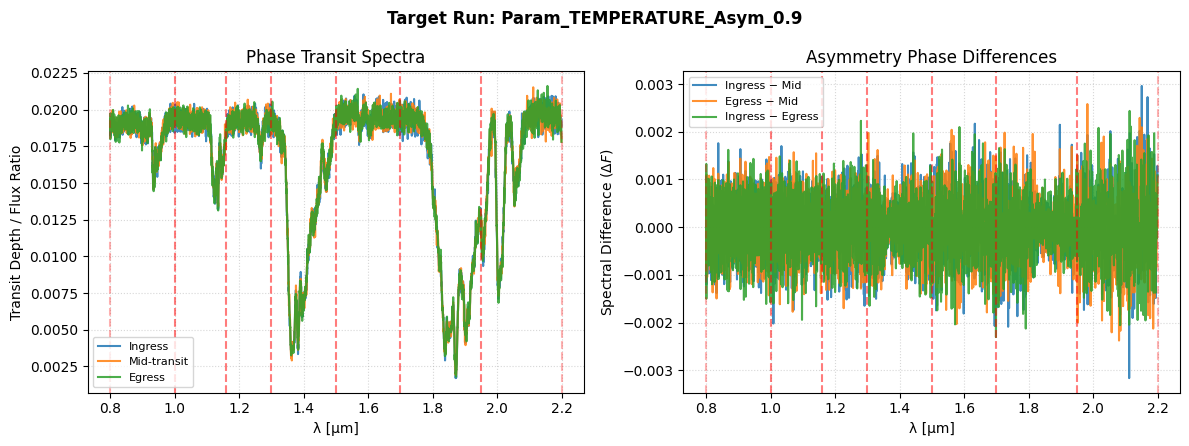

 REGIONAL METRICS FOR: Param_TEMPERATURE_Asym_0.9


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,-0.000053,0.037156,0.000422,0.000012,5.937167,0.854985
1,1.00-1.16,-0.000564,0.047765,0.000438,0.000015,4.349557,0.945598
2,1.16-1.30,0.000026,0.054305,0.000469,0.000019,6.196017,0.589538
3,1.30-1.50,-0.002483,0.049055,0.000400,0.000015,3.296297,0.995069
4,1.50-1.70,-0.001018,0.052715,0.000542,0.000022,5.816045,0.271913
5,1.70-1.95,0.000463,0.049735,0.000456,0.000017,3.142635,0.995258
6,1.95-2.20,-0.000754,0.052865,0.000600,0.000026,4.020994,0.976524



GLOBAL METRICS FOR: Param_TEMPERATURE_Asym_0.9


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_TEMPERATURE_Asym_0.9,0.000595,0.000008,-0.000094,0.002581


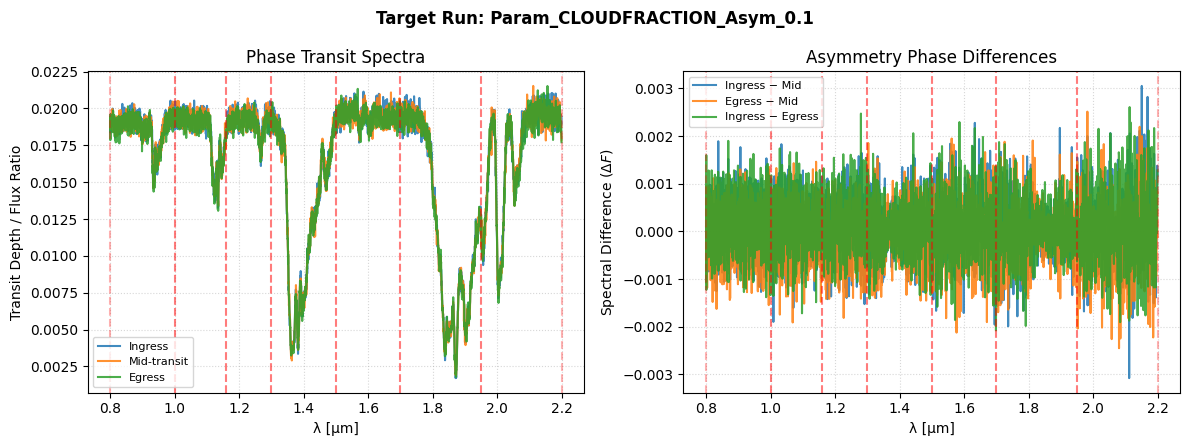

 REGIONAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.1


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.463424,0.037156,0.000468,0.000013,5.937167,0.854738
1,1.00-1.16,0.418783,0.047765,0.000477,0.000017,4.349557,0.945512
2,1.16-1.30,0.381988,0.054305,0.000503,0.000021,6.196017,0.589302
3,1.30-1.50,0.202818,0.049055,0.000411,0.000016,3.296297,0.995053
4,1.50-1.70,0.289044,0.052715,0.000565,0.000022,5.816045,0.271204
5,1.70-1.95,0.175082,0.049735,0.000465,0.000018,3.142635,0.995255
6,1.95-2.20,0.183168,0.052865,0.000610,0.000026,4.020994,0.976512



GLOBAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.1


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_CLOUDFRACTION_Asym_0.1,0.000627,0.000008,0.043565,0.002583


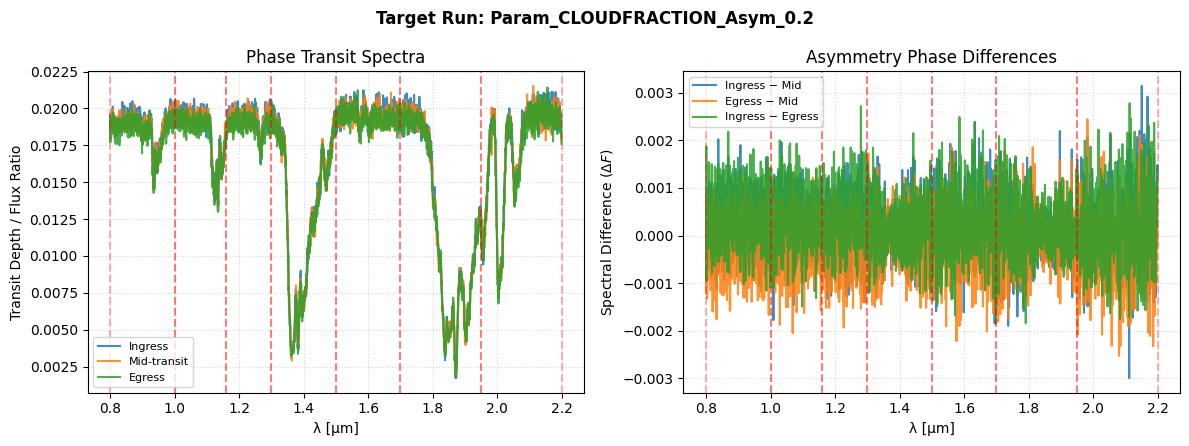

 REGIONAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.2


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.927225,0.037156,0.000594,0.000016,5.937167,0.853967
1,1.00-1.16,0.838429,0.047765,0.000587,0.000020,4.349557,0.945247
2,1.16-1.30,0.764230,0.054305,0.000600,0.000023,6.196017,0.588531
3,1.30-1.50,0.408332,0.049055,0.000442,0.000017,3.296297,0.995009
4,1.50-1.70,0.579343,0.052715,0.000631,0.000024,5.816045,0.269045
5,1.70-1.95,0.349872,0.049735,0.000494,0.000019,3.142635,0.995244
6,1.95-2.20,0.367297,0.052865,0.000642,0.000027,4.020994,0.976468



GLOBAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.2


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_CLOUDFRACTION_Asym_0.2,0.000715,0.000009,0.087259,0.002586


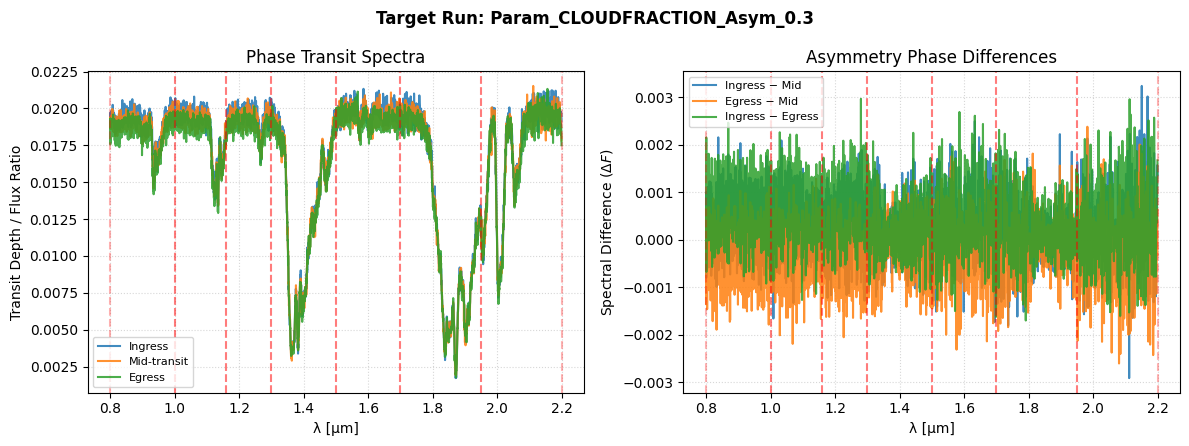

 REGIONAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.3


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,1.391698,0.037157,0.000780,0.000018,5.937167,0.852668
1,1.00-1.16,1.258666,0.047765,0.000751,0.000023,4.349557,0.944801
2,1.16-1.30,1.147023,0.054305,0.000748,0.000026,6.196017,0.587219
3,1.30-1.50,0.614253,0.049055,0.000493,0.000019,3.296297,0.994934
4,1.50-1.70,0.870131,0.052715,0.000737,0.000027,5.816045,0.265443
5,1.70-1.95,0.525014,0.049735,0.000539,0.000020,3.142635,0.995226
6,1.95-2.20,0.551830,0.052865,0.000695,0.000028,4.020994,0.976393



GLOBAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.3


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_CLOUDFRACTION_Asym_0.3,0.000842,0.00001,0.131023,0.002589


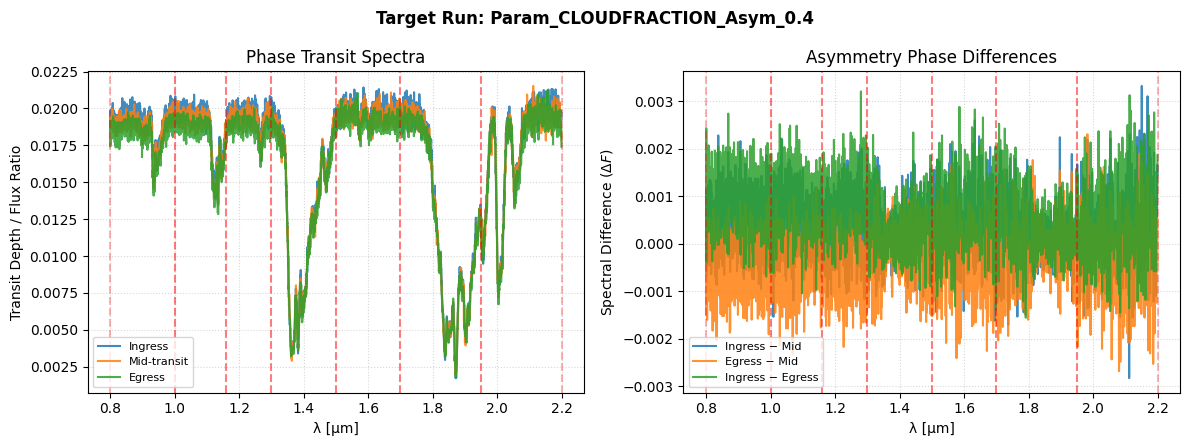

 REGIONAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.4


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,1.857194,0.037157,0.001000,0.000019,5.937167,0.850838
1,1.00-1.16,1.679817,0.047765,0.000950,0.000025,4.349557,0.944173
2,1.16-1.30,1.530670,0.054305,0.000933,0.000029,6.196017,0.585365
3,1.30-1.50,0.820797,0.049055,0.000559,0.000020,3.296297,0.994831
4,1.50-1.70,1.161655,0.052715,0.000874,0.000030,5.816045,0.260425
5,1.70-1.95,0.700688,0.049736,0.000599,0.000022,3.142635,0.995201
6,1.95-2.20,0.736993,0.052865,0.000767,0.000030,4.020994,0.976286



GLOBAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.4


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_CLOUDFRACTION_Asym_0.4,0.000993,0.00001,0.174895,0.002593


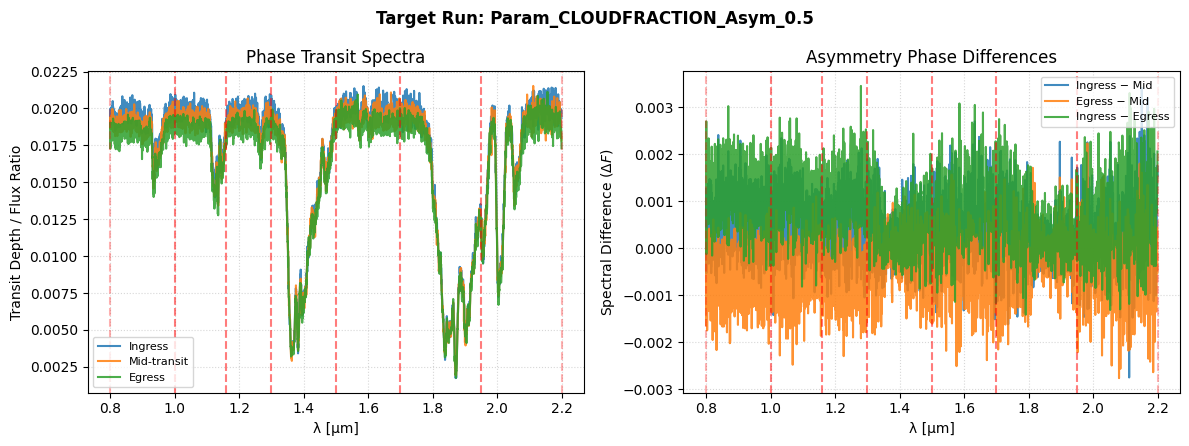

 REGIONAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.5


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,2.324083,0.037157,0.001238,0.000019,5.937167,0.848470
1,1.00-1.16,2.102219,0.047765,0.001168,0.000025,4.349557,0.943360
2,1.16-1.30,1.915481,0.054305,0.001139,0.000030,6.196017,0.582976
3,1.30-1.50,1.028206,0.049055,0.000637,0.000021,3.296297,0.994697
4,1.50-1.70,1.454181,0.052715,0.001035,0.000032,5.816045,0.254014
5,1.70-1.95,0.877087,0.049736,0.000672,0.000024,3.142635,0.995168
6,1.95-2.20,0.923022,0.052865,0.000855,0.000032,4.020994,0.976147



GLOBAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.5


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_CLOUDFRACTION_Asym_0.5,0.001159,0.00001,0.218914,0.002598


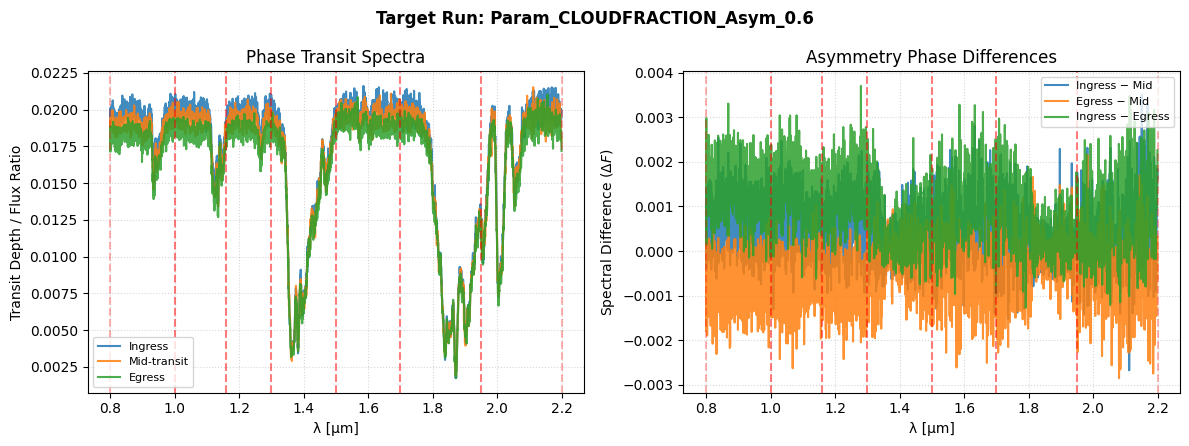

 REGIONAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.6


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,2.792801,0.037157,0.001483,0.000020,5.937167,0.845557
1,1.00-1.16,2.526217,0.047765,0.001395,0.000026,4.349557,0.942358
2,1.16-1.30,2.301794,0.054305,0.001358,0.000031,6.196017,0.580054
3,1.30-1.50,1.236710,0.049055,0.000724,0.000022,3.296297,0.994534
4,1.50-1.70,1.748001,0.052715,0.001213,0.000034,5.816045,0.246253
5,1.70-1.95,1.054440,0.049736,0.000754,0.000025,3.142635,0.995129
6,1.95-2.20,1.110173,0.052865,0.000958,0.000033,4.020994,0.975975



GLOBAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.6


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_CLOUDFRACTION_Asym_0.6,0.001335,0.00001,0.263124,0.002603


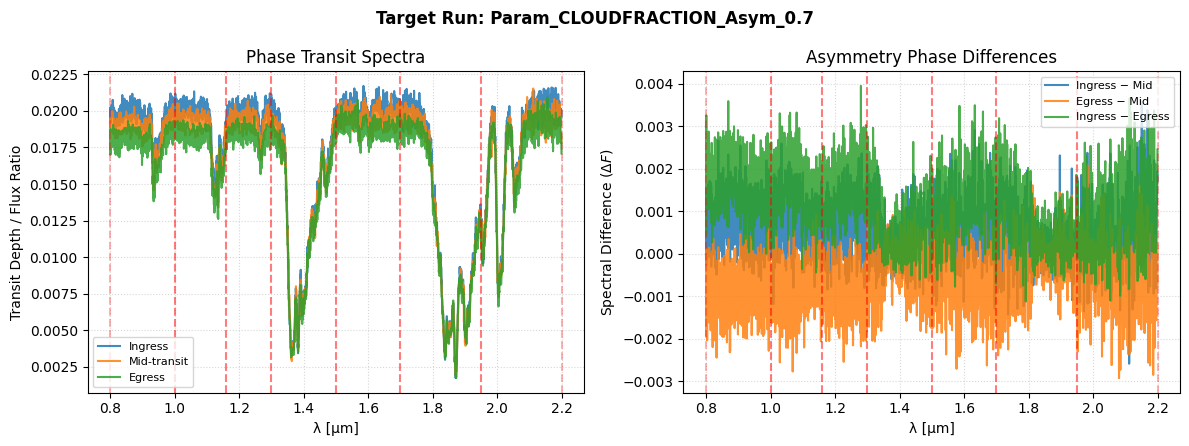

 REGIONAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.7


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,3.263797,0.037157,0.001732,0.000020,5.937167,0.842088
1,1.00-1.16,2.952232,0.047765,0.001628,0.000026,4.349557,0.941162
2,1.16-1.30,2.689980,0.054305,0.001584,0.000032,6.196017,0.576601
3,1.30-1.50,1.446590,0.049055,0.000819,0.000023,3.296297,0.994340
4,1.50-1.70,2.043427,0.052715,0.001401,0.000035,5.816045,0.237184
5,1.70-1.95,1.232972,0.049736,0.000844,0.000026,3.142635,0.995082
6,1.95-2.20,1.298716,0.052865,0.001072,0.000035,4.020994,0.975769



GLOBAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.7


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_CLOUDFRACTION_Asym_0.7,0.001518,0.000011,0.307575,0.002609


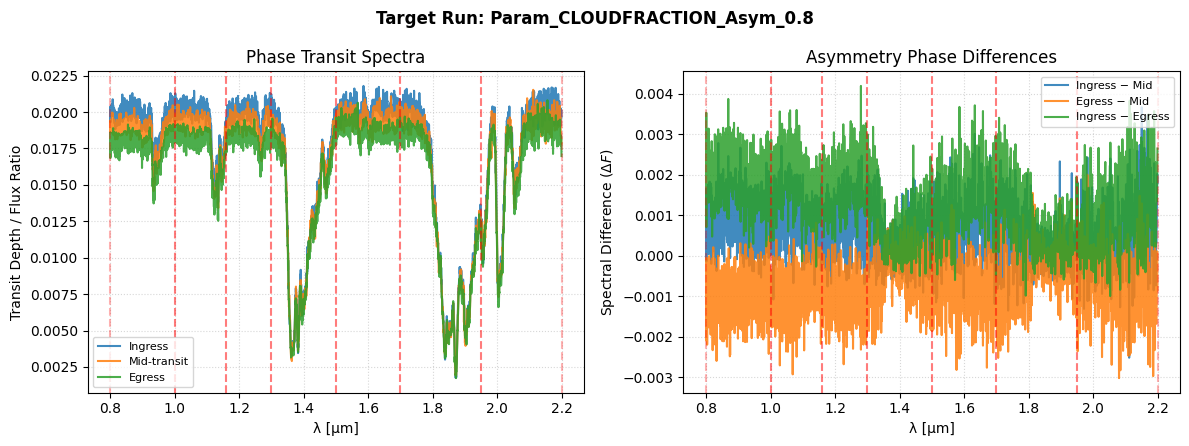

 REGIONAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.8


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,3.737568,0.037157,0.001983,0.000020,5.937167,0.838049
1,1.00-1.16,3.380642,0.047766,0.001863,0.000026,4.349557,0.939768
2,1.16-1.30,3.080367,0.054305,0.001812,0.000032,6.196017,0.572613
3,1.30-1.50,1.658087,0.049055,0.000919,0.000024,3.296297,0.994116
4,1.50-1.70,2.340761,0.052715,0.001597,0.000035,5.816045,0.226854
5,1.70-1.95,1.412903,0.049736,0.000940,0.000027,3.142635,0.995028
6,1.95-2.20,1.488961,0.052865,0.001196,0.000036,4.020994,0.975528



GLOBAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.8


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_CLOUDFRACTION_Asym_0.8,0.001706,0.000011,0.352315,0.002616


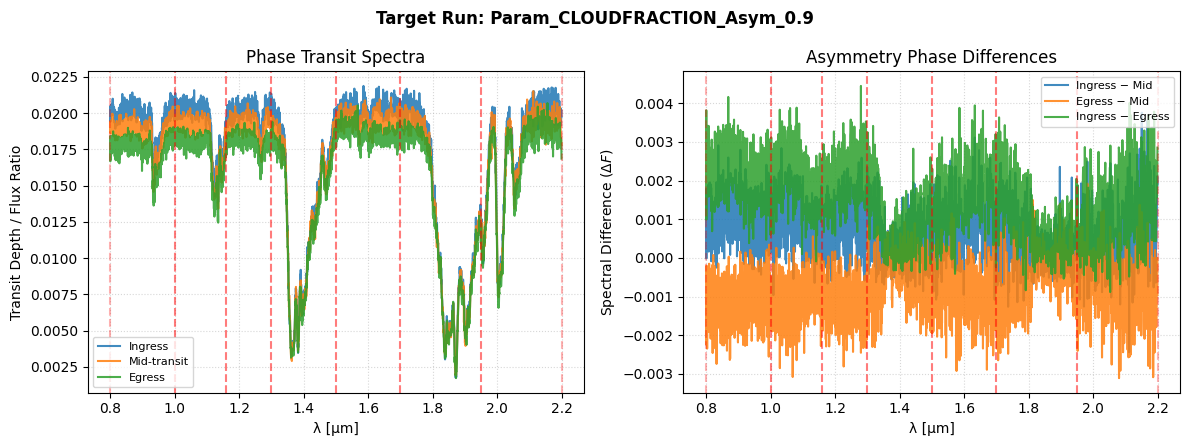

 REGIONAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.9


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,4.214377,0.037157,0.002236,0.000020,5.937167,0.833423
1,1.00-1.16,3.811578,0.047766,0.002100,0.000026,4.349557,0.938168
2,1.16-1.30,3.473007,0.054305,0.002043,0.000032,6.196017,0.568115
3,1.30-1.50,1.871212,0.049055,0.001024,0.000024,3.296297,0.993860
4,1.50-1.70,2.640004,0.052715,0.001797,0.000036,5.816045,0.215335
5,1.70-1.95,1.594294,0.049736,0.001041,0.000027,3.142635,0.994966
6,1.95-2.20,1.681054,0.052865,0.001329,0.000037,4.020994,0.975252



GLOBAL METRICS FOR: Param_CLOUDFRACTION_Asym_0.9


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_CLOUDFRACTION_Asym_0.9,0.001899,0.000011,0.39736,0.002623


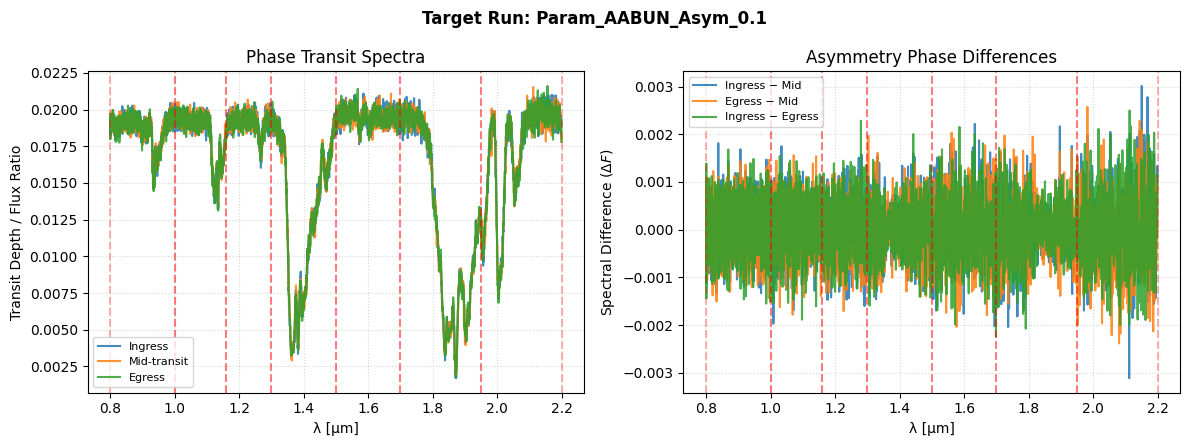

 REGIONAL METRICS FOR: Param_AABUN_Asym_0.1


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.111378,0.037156,0.000425,0.000012,5.937167,0.855305
1,1.00-1.16,0.099496,0.047765,0.000440,0.000015,4.349557,0.945721
2,1.16-1.30,0.094203,0.054305,0.000471,0.000019,6.196017,0.590039
3,1.30-1.50,0.066000,0.049055,0.000401,0.000016,3.296297,0.995079
4,1.50-1.70,0.080463,0.052715,0.000544,0.000021,5.816045,0.272156
5,1.70-1.95,0.058421,0.049735,0.000457,0.000017,3.142635,0.995268
6,1.95-2.20,0.066960,0.052865,0.000601,0.000026,4.020994,0.976578



GLOBAL METRICS FOR: Param_AABUN_Asym_0.1


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_AABUN_Asym_0.1,0.000598,0.000008,0.011745,0.002579


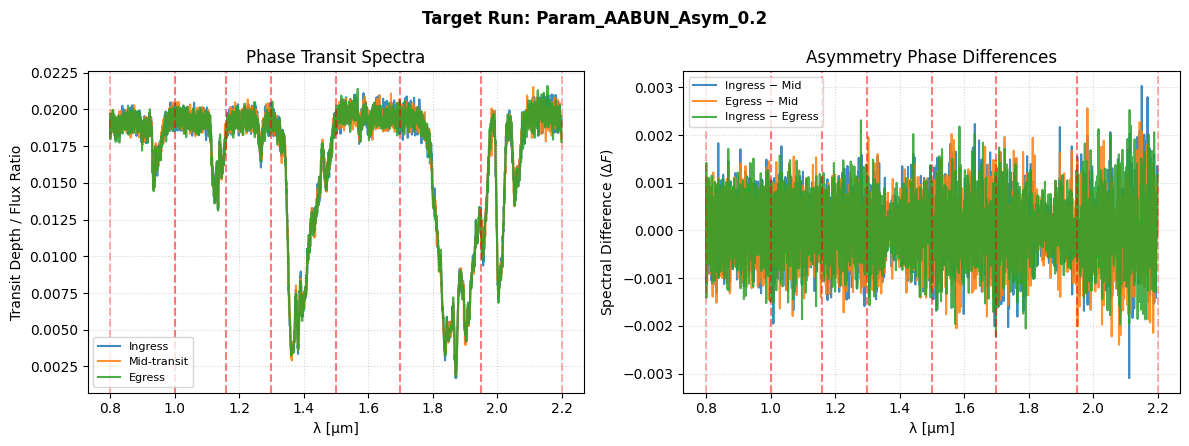

 REGIONAL METRICS FOR: Param_AABUN_Asym_0.2


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.164250,0.037156,0.000428,0.000013,5.937167,0.855365
1,1.00-1.16,0.146389,0.047765,0.000443,0.000016,4.349557,0.945742
2,1.16-1.30,0.138024,0.054305,0.000473,0.000019,6.196017,0.590121
3,1.30-1.50,0.097766,0.049055,0.000402,0.000016,3.296297,0.995080
4,1.50-1.70,0.118253,0.052715,0.000546,0.000022,5.816045,0.272180
5,1.70-1.95,0.085516,0.049735,0.000458,0.000017,3.142635,0.995269
6,1.95-2.20,0.099025,0.052865,0.000602,0.000026,4.020994,0.976587



GLOBAL METRICS FOR: Param_AABUN_Asym_0.2


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_AABUN_Asym_0.2,0.0006,0.000008,0.017296,0.002578


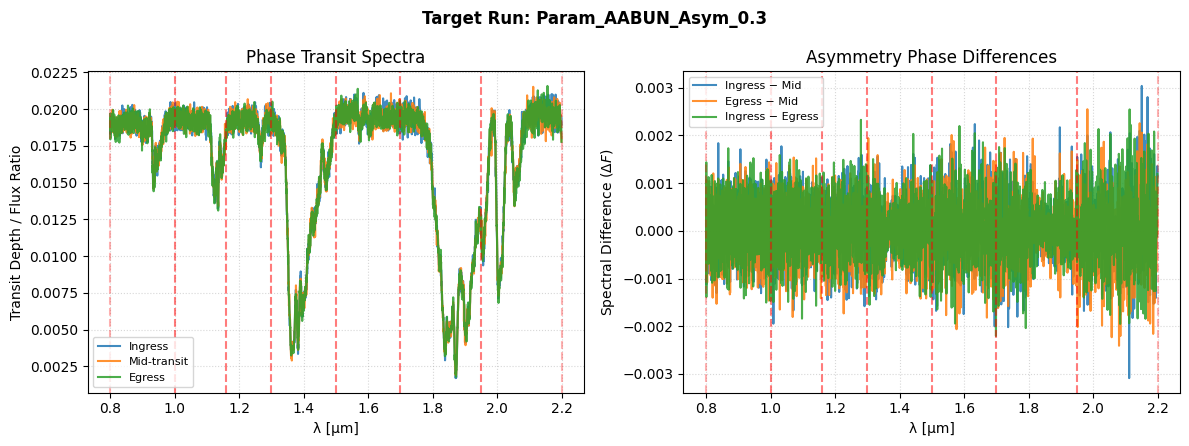

 REGIONAL METRICS FOR: Param_AABUN_Asym_0.3


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.203405,0.037156,0.000431,0.000013,5.937167,0.855337
1,1.00-1.16,0.181156,0.047765,0.000445,0.000016,4.349557,0.945729
2,1.16-1.30,0.170535,0.054305,0.000476,0.000019,6.196017,0.590062
3,1.30-1.50,0.121296,0.049055,0.000403,0.000016,3.296297,0.995079
4,1.50-1.70,0.146293,0.052715,0.000548,0.000022,5.816045,0.272132
5,1.70-1.95,0.105551,0.049735,0.000459,0.000017,3.142635,0.995268
6,1.95-2.20,0.122733,0.052865,0.000604,0.000026,4.020994,0.976582



GLOBAL METRICS FOR: Param_AABUN_Asym_0.3


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_AABUN_Asym_0.3,0.000603,0.000008,0.021412,0.002579


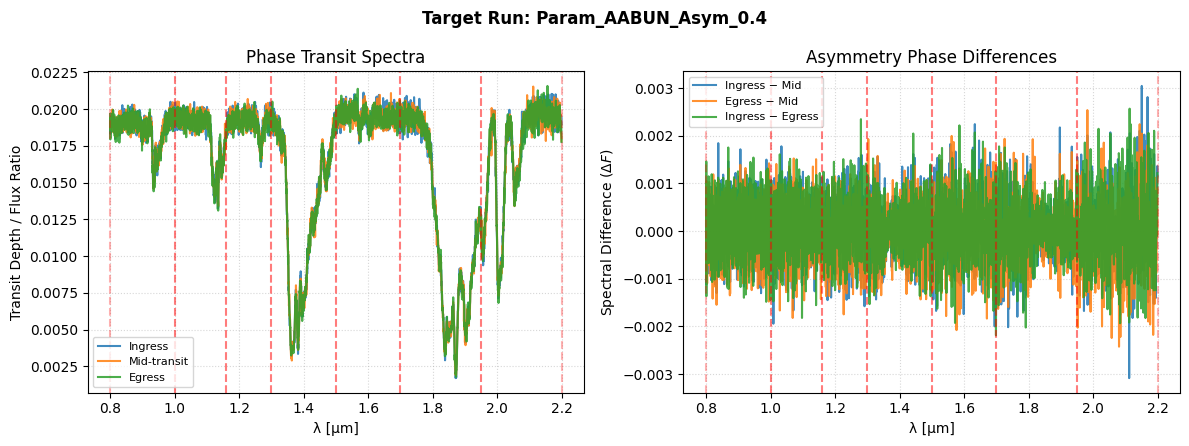

 REGIONAL METRICS FOR: Param_AABUN_Asym_0.4


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.240475,0.037156,0.000435,0.000013,5.937167,0.855257
1,1.00-1.16,0.214345,0.047765,0.000448,0.000016,4.349557,0.945696
2,1.16-1.30,0.201733,0.054305,0.000479,0.000020,6.196017,0.589923
3,1.30-1.50,0.143856,0.049055,0.000405,0.000016,3.296297,0.995076
4,1.50-1.70,0.173261,0.052715,0.000550,0.000022,5.816045,0.272047
5,1.70-1.95,0.124665,0.049735,0.000460,0.000017,3.142635,0.995265
6,1.95-2.20,0.145155,0.052865,0.000606,0.000026,4.020994,0.976568



GLOBAL METRICS FOR: Param_AABUN_Asym_0.4


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_AABUN_Asym_0.4,0.000606,0.000008,0.025342,0.00258


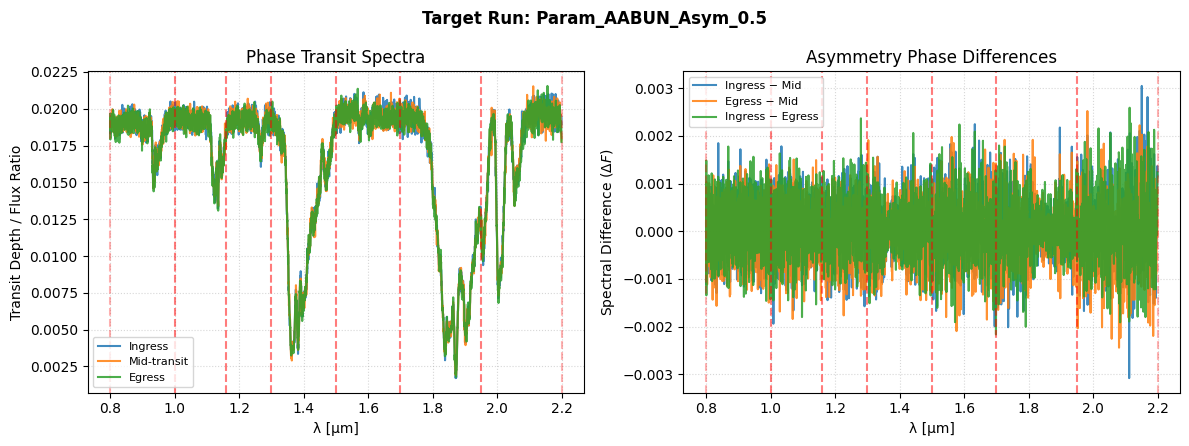

 REGIONAL METRICS FOR: Param_AABUN_Asym_0.5


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.281337,0.037156,0.000439,0.000013,5.937167,0.855132
1,1.00-1.16,0.251327,0.047765,0.000452,0.000016,4.349557,0.945646
2,1.16-1.30,0.236717,0.054305,0.000482,0.000020,6.196017,0.589713
3,1.30-1.50,0.169161,0.049055,0.000406,0.000016,3.296297,0.995071
4,1.50-1.70,0.203571,0.052715,0.000553,0.000022,5.816045,0.271924
5,1.70-1.95,0.145942,0.049735,0.000462,0.000017,3.142635,0.995261
6,1.95-2.20,0.169852,0.052865,0.000608,0.000026,4.020994,0.976546



GLOBAL METRICS FOR: Param_AABUN_Asym_0.5


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_AABUN_Asym_0.5,0.00061,0.000008,0.029721,0.002581


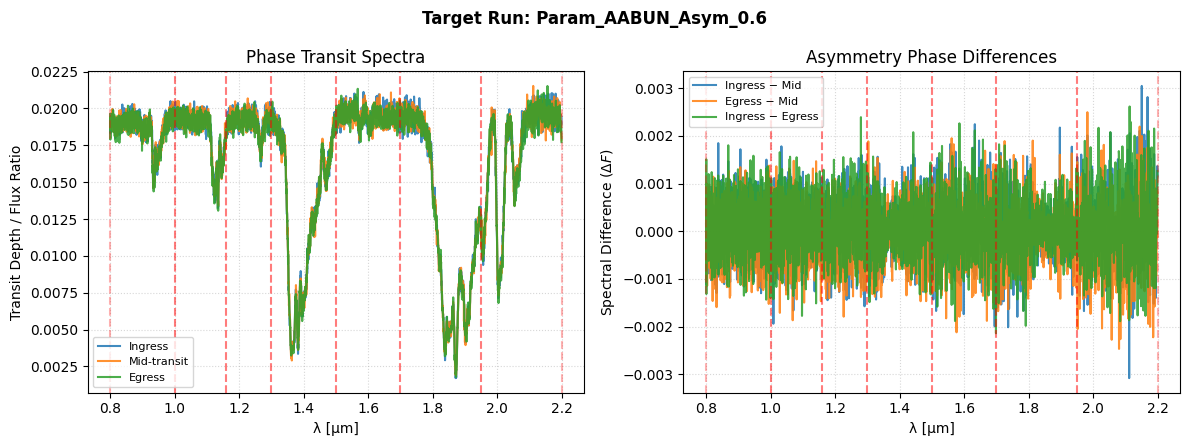

 REGIONAL METRICS FOR: Param_AABUN_Asym_0.6


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.331332,0.037156,0.000445,0.000013,5.937167,0.854954
1,1.00-1.16,0.297035,0.047765,0.000457,0.000016,4.349557,0.945574
2,1.16-1.30,0.280187,0.054305,0.000487,0.000020,6.196017,0.589413
3,1.30-1.50,0.200591,0.049055,0.000409,0.000016,3.296297,0.995065
4,1.50-1.70,0.241316,0.052715,0.000558,0.000022,5.816045,0.271758
5,1.70-1.95,0.172198,0.049735,0.000464,0.000018,3.142635,0.995255
6,1.95-2.20,0.200029,0.052865,0.000612,0.000026,4.020994,0.976515



GLOBAL METRICS FOR: Param_AABUN_Asym_0.6


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_AABUN_Asym_0.6,0.000615,0.000008,0.035132,0.002583


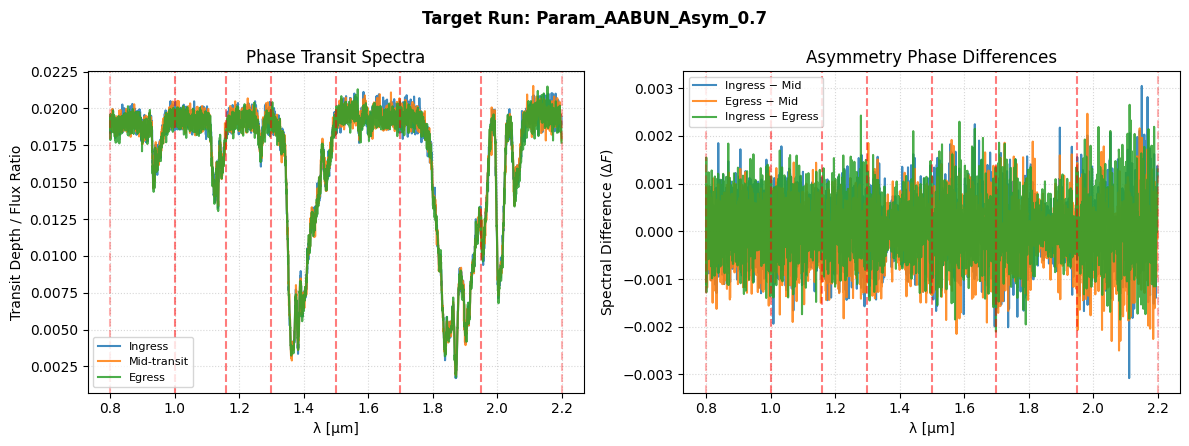

 REGIONAL METRICS FOR: Param_AABUN_Asym_0.7


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.398276,0.037156,0.000456,0.000013,5.937167,0.854698
1,1.00-1.16,0.358744,0.047765,0.000466,0.000017,4.349557,0.945471
2,1.16-1.30,0.339182,0.054305,0.000496,0.000020,6.196017,0.588988
3,1.30-1.50,0.243123,0.049055,0.000413,0.000016,3.296297,0.995056
4,1.50-1.70,0.292598,0.052715,0.000565,0.000022,5.816045,0.271534
5,1.70-1.95,0.207563,0.049735,0.000468,0.000018,3.142635,0.995246
6,1.95-2.20,0.240319,0.052865,0.000617,0.000026,4.020994,0.976470



GLOBAL METRICS FOR: Param_AABUN_Asym_0.7


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_AABUN_Asym_0.7,0.000624,0.000008,0.042437,0.002586


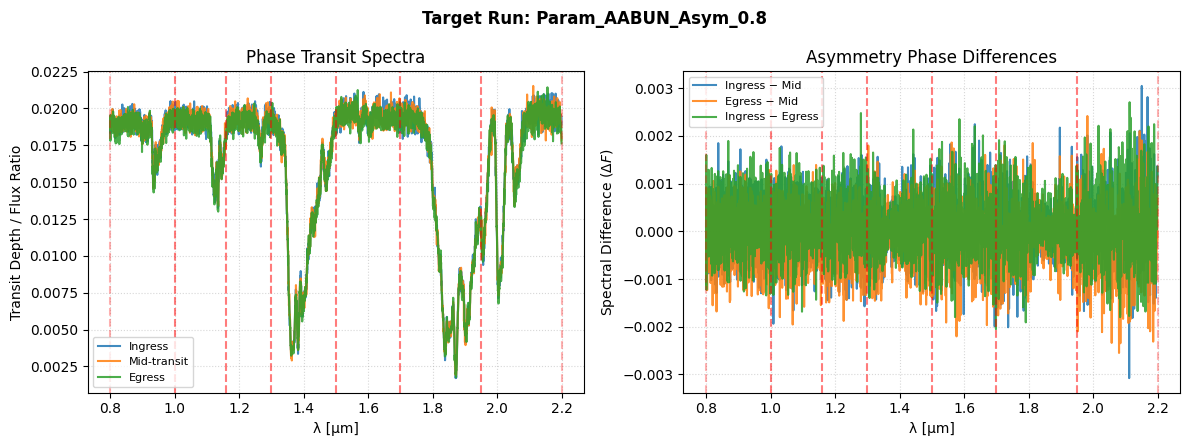

 REGIONAL METRICS FOR: Param_AABUN_Asym_0.8


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.498460,0.037156,0.000474,0.000013,5.937167,0.854302
1,1.00-1.16,0.451776,0.047765,0.000482,0.000017,4.349557,0.945310
2,1.16-1.30,0.428436,0.054305,0.000511,0.000021,6.196017,0.588333
3,1.30-1.50,0.307119,0.049055,0.000421,0.000017,3.296297,0.995043
4,1.50-1.70,0.370260,0.052715,0.000579,0.000022,5.816045,0.271197
5,1.70-1.95,0.260540,0.049735,0.000475,0.000018,3.142635,0.995233
6,1.95-2.20,0.300281,0.052865,0.000627,0.000026,4.020994,0.976401



GLOBAL METRICS FOR: Param_AABUN_Asym_0.8


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_AABUN_Asym_0.8,0.00064,0.000008,0.053445,0.00259


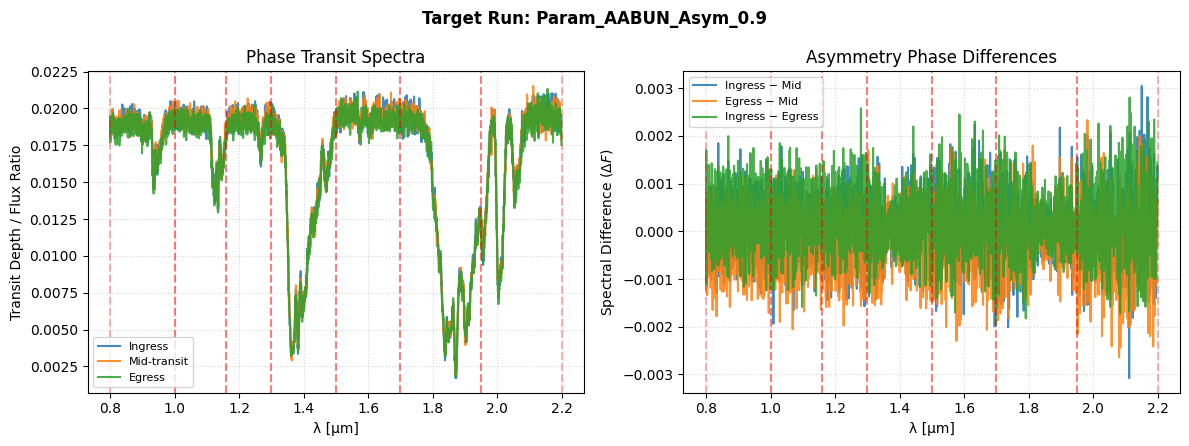

 REGIONAL METRICS FOR: Param_AABUN_Asym_0.9


,Region [um],σ_det,σ_det_err,|I-E|,|I-E|_err,Z_D,ρ
0,0.80-1.00,0.683006,0.037156,0.000518,0.000014,5.937167,0.853552
1,1.00-1.16,0.624261,0.047765,0.000521,0.000018,4.349557,0.945003
2,1.16-1.30,0.594598,0.054305,0.000550,0.000022,6.196017,0.587105
3,1.30-1.50,0.424487,0.049055,0.000441,0.000017,3.296297,0.995016
4,1.50-1.70,0.514601,0.052715,0.000612,0.000023,5.816045,0.270667
5,1.70-1.95,0.357367,0.049735,0.000491,0.000019,3.142635,0.995208
6,1.95-2.20,0.409255,0.052865,0.000651,0.000027,4.020994,0.976267



GLOBAL METRICS FOR: Param_AABUN_Asym_0.9


,Asymmetry Run,RMS,RMS_err,E,E_err
0,Param_AABUN_Asym_0.9,0.000677,0.000009,0.073834,0.002599


In [3]:
# STATISTICAL ANALYSIS AND MONTE CARLO SIMULATIONS
# Define spectral analysis wavelength regions [μm]
regions = [
    (0.80, 1.00),  # Rayleigh + optical continuum / H− slope
    (1.00, 1.16),  # Continuum baseline
    (1.16, 1.30),  # Weak H2O + continuum transition
    (1.30, 1.50),  # STRONG H2O band (main asymmetry signal)
    (1.50, 1.70),  # H2O wing / opacity plateau
    (1.70, 1.95),  # Second H2O band
    (1.95, 2.20)   # Deep IR tail (temperature + opacity interplay)
]
WORK_DIR = os.getcwd()
ANALYSIS_RESULTS = []
def load_phase_data(full_folder_path):
    """
    Load phase spectrum files (ingress, mid, egress) from a target folder.
    Cleans out potential NaN values and returns clean array tuples.
    """
    def load_one(phase_name):
        file_path = os.path.join(full_folder_path, f"{phase_name}.txt")
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Expected file missing: {file_path}")
        raw_arr = np.loadtxt(file_path)
        array_data = np.array(raw_arr)
        return array_data[~np.isnan(array_data).any(axis=1)]
    return (load_one("ingress"), load_one("mid"), load_one("egress"))
def bin_spectrum(λ_arr, flux_arr, σ_arr, nbins=30):
    """Bins spectrum into a specified number of wavelength channels using weighted averaging."""
    edges = np.linspace(λ_arr.min(), λ_arr.max(), nbins + 1)
    λ_bin = 0.5 * (edges[:-1] + edges[1:])
    f_bin = np.zeros(nbins)
    σ_bin = np.zeros(nbins)
    for b_idx in range(nbins):
        mask_bin = (λ_arr >= edges[b_idx]) & (λ_arr < edges[b_idx + 1])
        if np.any(mask_bin):
            weights = 1 / σ_arr[mask_bin]**2
            f_bin[b_idx] = np.sum(flux_arr[mask_bin] * weights) / np.sum(weights)
            σ_bin[b_idx] = np.sqrt(1 / np.sum(weights))
        else:
            f_bin[b_idx] = np.nan
            σ_bin[b_idx] = np.nan
    return λ_bin, f_bin, σ_bin
def plot_transit_spectra(λ_grid, f_ing, f_mid, f_egr, folder_label):
    """Visualizes ingress, mid, egress spectra and their phase differences."""
    fig, axes_spec = plt.subplots(1, 2, figsize=(12, 4.5))
    # Left subplot: Absolute transit spectra
    ax_left = axes_spec[0]
    ax_left.plot(λ_grid, f_ing, label="Ingress", alpha=0.85)
    ax_left.plot(λ_grid, f_mid, label="Mid-transit", alpha=0.85)
    ax_left.plot(λ_grid, f_egr, label="Egress", alpha=0.85)
    for r1_v, r2_v in regions:
        ax_left.axvline(r1_v, linestyle='--', color='red', alpha=0.3)
        ax_left.axvline(r2_v, linestyle='--', color='red', alpha=0.3)
    ax_left.set_xlabel(r"λ [μm]")
    ax_left.set_ylabel("Transit Depth / Flux Ratio")
    ax_left.set_title("Phase Transit Spectra")
    ax_left.legend(fontsize=8)
    ax_left.grid(True, linestyle=":", alpha=0.5)
    # Right subplot: Differential asymmetry spectra
    ax_right = axes_spec[1]
    ax_right.plot(λ_grid, f_ing - f_mid, label="Ingress − Mid", alpha=0.85)
    ax_right.plot(λ_grid, f_egr - f_mid, label="Egress − Mid", alpha=0.85)
    ax_right.plot(λ_grid, f_ing - f_egr, label="Ingress − Egress", alpha=0.85)
    for r1_v, r2_v in regions:
        ax_right.axvline(r1_v, linestyle='--', color='red', alpha=0.3)
        ax_right.axvline(r2_v, linestyle='--', color='red', alpha=0.3)
    ax_right.set_xlabel(r"λ [μm]")
    ax_right.set_ylabel(r"Spectral Difference ($ΔF$)")
    ax_right.set_title("Asymmetry Phase Differences")
    ax_right.legend(fontsize=8)
    ax_right.grid(True, linestyle=":", alpha=0.5)
    plt.suptitle(f"Target Run: {folder_label}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
def _calc_region_stats(mc_data, mask, i_err, e_err):
    """Computes single-region statistical metrics for a single Monte Carlo trial."""
    fi, fe, fm = mc_data[0][mask], mc_data[2][mask], mc_data[1][mask]
    diff = fi - fe
    # Signal detectability metric (signal-to-uncertainty ratio)
    s_det = np.mean(diff / np.sqrt(i_err[mask]**2 + e_err[mask]**2))
    diff_abs = np.mean(np.abs(diff))
    # Dynamic Z-score and Pearson correlation between limbs
    z_d = (np.max(fm) - np.min(fm)) / np.std(fm) if np.std(fm) > 0 else np.nan
    ρ_val = np.corrcoef(fi, fe)[0, 1] if (len(fi) > 1 and np.std(fi) > 0 and np.std(fe) > 0) else np.nan
    return s_det, diff_abs, z_d, ρ_val
def _run_mc_simulations(λ_grid, phase_data_tuple, rng, n_mc=1000):
    """Executes Monte Carlo error propagation across wavelength regions and global metrics."""
    mc_res = {r_idx: {'σ_det': [], '|I-E|': [], 'z_d': [], 'ρ': []}
              for r_idx in range(len(regions))}
    g_rms, g_e = [], []
    for _ in range(n_mc):
        # Inject Gaussian noise based on PSG parameter uncertainties (column index 2)
        mc_data = (
            phase_data_tuple[0][:, -1] + rng.normal(0.0, phase_data_tuple[0][:, 2]),
            phase_data_tuple[1][:, -1] + rng.normal(0.0, phase_data_tuple[1][:, 2]),
            phase_data_tuple[2][:, -1] + rng.normal(0.0, phase_data_tuple[2][:, 2])
        )
        # Calculate global RMS and asymmetry significance metric E
        g_rms.append(np.sqrt(np.mean((mc_data[0] - mc_data[2])**2)))
        g_e.append((np.mean(mc_data[0]) - np.mean(mc_data[2])) / 
                   np.sqrt((np.std(mc_data[0])**2 + np.std(mc_data[2])**2) / 2))
        # Region-by-region evaluation
        for r_idx, reg in enumerate(regions):
            mask_reg = (λ_grid >= reg[0]) & (λ_grid <= reg[1])
            stats = _calc_region_stats(mc_data, mask_reg, phase_data_tuple[0][:, 2], phase_data_tuple[2][:, 2])
            mc_res[r_idx]['σ_det'].append(stats[0])
            mc_res[r_idx]['|I-E|'].append(stats[1])
            if not np.isnan(stats[2]):
                mc_res[r_idx]['z_d'].append(stats[2])
            if not np.isnan(stats[3]):
                mc_res[r_idx]['ρ'].append(stats[3])
    return mc_res, g_rms, g_e
def _build_regional_df(mc_results):
    """Constructs a clean pandas DataFrame summarizing Monte Carlo regional statistics."""
    regional_rows = []
    for r_idx, (r1_v, r2_v) in enumerate(regions):
        s_vals = np.array(mc_results[r_idx]['σ_det'])
        d_vals = np.array(mc_results[r_idx]['|I-E|'])
        z_vals = np.array(mc_results[r_idx]['z_d']) if mc_results[r_idx]['z_d'] else np.array([np.nan])
        r_vals = np.array(mc_results[r_idx]['ρ']) if mc_results[r_idx]['ρ'] else np.array([np.nan])
        regional_rows.append({
            'Region [um]': f"{r1_v:.2f}-{r2_v:.2f}",
            'σ_det': np.mean(s_vals), 
            'σ_det_err': np.std(s_vals),
            '|I-E|': np.mean(d_vals), 
            '|I-E|_err': np.std(d_vals),
            'Z_D': np.nanmean(z_vals), 
            'ρ': np.nanmean(r_vals)
        })
    return pd.DataFrame(regional_rows)
def analiza(full_folder_path):
    """
    Main statistical driver function: loads data, generates spectra plots, 
    runs Monte Carlo iterations, and prints formatted DataFrames.
    """
    folder_label = os.path.basename(full_folder_path)
    i_data, m_data, e_data = load_phase_data(full_folder_path)
    λ_grid = i_data[:, 0]
    rng = np.random.default_rng(42)
    # Synthetic realization for plotting
    f_ing = i_data[:, -1] + rng.normal(0.0, i_data[:, 2])
    f_mid = m_data[:, -1] + rng.normal(0.0, m_data[:, 2])
    f_egr = e_data[:, -1] + rng.normal(0.0, e_data[:, 2])
    # Render spectral plots
    plot_transit_spectra(λ_grid, f_ing, f_mid, f_egr, folder_label)
    # Run MC Simulation
    mc_res, g_rms, g_e = _run_mc_simulations(λ_grid, (i_data, m_data, e_data), rng)
    print(f" REGIONAL METRICS FOR: {folder_label}")
    display(_build_regional_df(mc_res))
    global_df = pd.DataFrame([{
        "Asymmetry Run": folder_label,
        "RMS": np.mean(g_rms), 
        "RMS_err": np.std(g_rms),
        "E": np.mean(g_e), 
        "E_err": np.std(g_e)
    }])
    print(f"\nGLOBAL METRICS FOR: {folder_label}")
    display(global_df)
    return (folder_label, np.mean(g_rms), np.std(g_rms), np.mean(g_e), np.std(g_e))
# DYNAMIC BATCH EXECUTION ACROSS ALL PARAMETER SWEEPS
ASYMMETRY_LEVELS = np.arange(0.1, 1.0, 0.1)
PARAMS = ["TEMPERATURE", "CLOUDFRACTION", "AABUN"]
# Generate folder list dynamically
TARGET_FOLDERS = []
for p in PARAMS:
    for a in ASYMMETRY_LEVELS:
        TARGET_FOLDERS.append(f"Param_{p}_Asym_{a:.1f}")
# Execute loop across output_results directory
for folder_item in TARGET_FOLDERS:
    full_folder_path = os.path.join(WORK_DIR, "output_results", folder_item)
    if os.path.exists(full_folder_path):
        res = analiza(full_folder_path)
        ANALYSIS_RESULTS.append(res)
    else:
        print(f"Directory skipped (not found): {full_folder_path}")

In [4]:
# ADVANCED STATISTICAL ANALYSIS (CHI-SQUARED, LOG-LIKELIHOOD & DETECTION SIGNIFICANCE)
summary_records = []
for folder_item in TARGET_FOLDERS:
    full_path = os.path.join(WORK_DIR, "output_results", folder_item)
    if not os.path.exists(full_path):
        continue
    parts = folder_item.split("_")
    param_name, asym_level = parts[1], float(parts[3])
    ing_data, mid_data, egr_data = load_phase_data(full_path)
    λ_grid = ing_data[:, 0]
    f_ing, f_egr = ing_data[:, -1], egr_data[:, -1]
    σ_ing, σ_egr = ing_data[:, 2], egr_data[:, 2]
    σ_comb = np.sqrt(σ_ing**2 + σ_egr**2)
    ΔF = f_ing - f_egr
    chi2 = np.sum((ΔF / σ_comb)**2)
    dof = len(λ_grid)
    chi2_red = chi2 / dof
    log_likelihood = -0.5 * np.sum((ΔF / σ_comb)**2 + np.log(2 * np.pi * σ_comb**2))
    rms_diff = np.sqrt(np.mean(ΔF**2))
    mean_σ_det = np.mean(np.abs(ΔF) / σ_comb)
    max_σ_det = np.max(np.abs(ΔF) / σ_comb)
    summary_records.append({
        'Folder': folder_item, 'Parameter': param_name, 'α': asym_level,
        'RMS [Flux Ratio]': rms_diff, 'Mean σ_det': mean_σ_det,
        'Max σ_det': max_σ_det, 'χ²_red': chi2_red, 'ln(L)': log_likelihood
    })
df_summary = pd.DataFrame(summary_records)
print("STATISTICAL SUMMARY ACROSS ALL ATMOSPHERIC SWEEPS")
display(df_summary.head(10))

STATISTICAL SUMMARY ACROSS ALL ATMOSPHERIC SWEEPS


,Folder,Parameter,α,RMS [Flux Ratio],Mean σ_det,Max σ_det,χ²_red,ln(L)
0,Param_TEMPERATURE_Asym_0.1,TEMPERATURE,0.1,0.000000,0.000000,0.000000,0.000000,19861.555631
1,Param_TEMPERATURE_Asym_0.2,TEMPERATURE,0.2,0.000000,0.000000,0.000000,0.000000,19861.555631
2,Param_TEMPERATURE_Asym_0.3,TEMPERATURE,0.3,0.000000,0.000000,0.000000,0.000000,19861.555631
3,Param_TEMPERATURE_Asym_0.4,TEMPERATURE,0.4,0.000000,0.000000,0.000000,0.000000,19861.555631
4,Param_TEMPERATURE_Asym_0.5,TEMPERATURE,0.5,0.000000,0.000000,0.000000,0.000000,19861.555631
5,Param_TEMPERATURE_Asym_0.6,TEMPERATURE,0.6,0.000000,0.000000,0.000000,0.000000,19861.555631
6,Param_TEMPERATURE_Asym_0.7,TEMPERATURE,0.7,0.000000,0.000000,0.000000,0.000000,19861.555631
7,Param_TEMPERATURE_Asym_0.8,TEMPERATURE,0.8,0.000000,0.000000,0.000000,0.000000,19861.555631
8,Param_TEMPERATURE_Asym_0.9,TEMPERATURE,0.9,0.000000,0.000000,0.000000,0.000000,19861.555631
9,Param_CLOUDFRACTION_Asym_0.1,CLOUDFRACTION,0.1,0.000198,0.317308,0.532053,0.117506,19683.180251


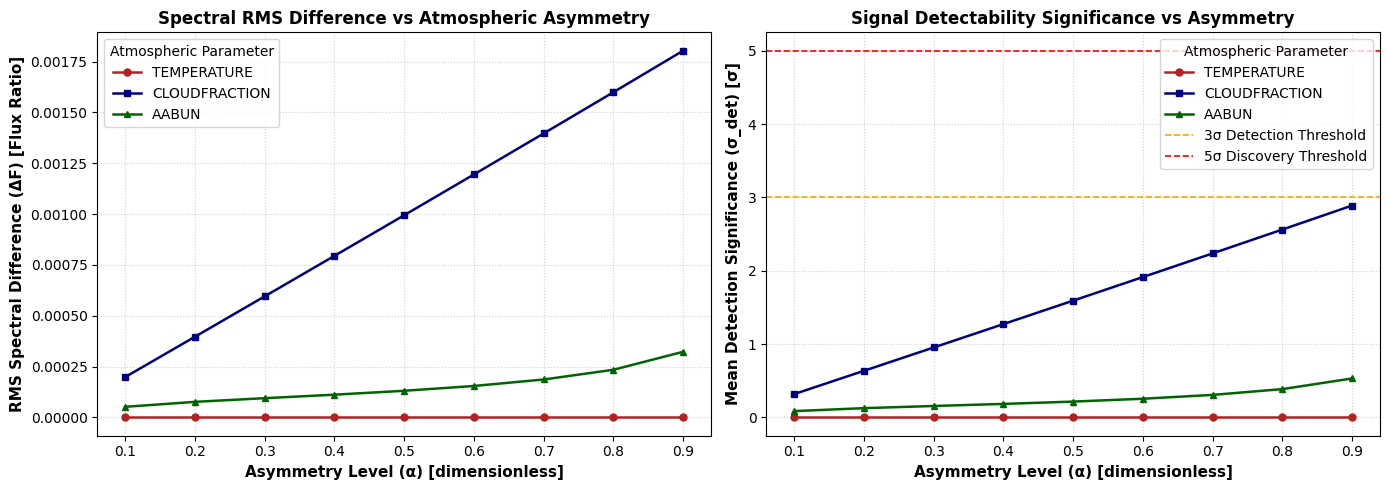

In [5]:
# PARAMETER COMPARISON (RMS DIFFERENCE & DETECTION SIGNIFICANCE OVER ASYMMETRY α)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'TEMPERATURE': 'firebrick', 'CLOUDFRACTION': 'navy', 'AABUN': 'darkgreen'}
markers = {'TEMPERATURE': 'o', 'CLOUDFRACTION': 's', 'AABUN': '^'}
ax1 = axes[0]
for param in PARAMS:
    sub_df = df_summary[df_summary['Parameter'] == param].sort_values('α')
    ax1.plot(sub_df['α'], sub_df['RMS [Flux Ratio]'], label=param, color=colors[param],
             marker=markers[param], linewidth=1.8, markersize=5)
ax1.set_xlabel("Asymmetry Level (α) [dimensionless]", fontsize=11, fontweight='bold')
ax1.set_ylabel("RMS Spectral Difference (ΔF) [Flux Ratio]", fontsize=11, fontweight='bold')
ax1.set_title("Spectral RMS Difference vs Atmospheric Asymmetry", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(title="Atmospheric Parameter")
ax2 = axes[1]
for param in PARAMS:
    sub_df = df_summary[df_summary['Parameter'] == param].sort_values('α')
    ax2.plot(sub_df['α'], sub_df['Mean σ_det'], label=param, color=colors[param],
             marker=markers[param], linewidth=1.8, markersize=5)
ax2.axhline(3.0, color='orange', linestyle='--', linewidth=1.2, label='3σ Detection Threshold')
ax2.axhline(5.0, color='red', linestyle='--', linewidth=1.2, label='5σ Discovery Threshold')
ax2.set_xlabel("Asymmetry Level (α) [dimensionless]", fontsize=11, fontweight='bold')
ax2.set_ylabel("Mean Detection Significance (σ_det) [σ]", fontsize=11, fontweight='bold')
ax2.set_title("Signal Detectability Significance vs Asymmetry", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(title="Atmospheric Parameter")
plt.tight_layout()
plt.show()

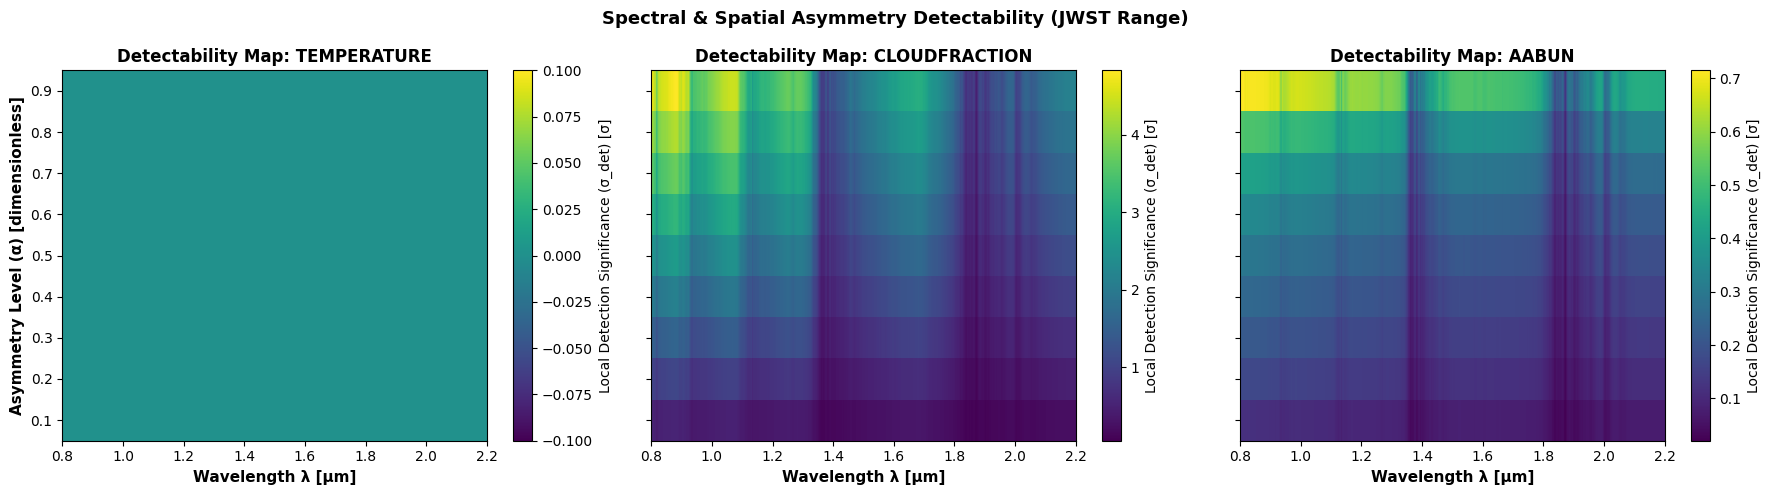

In [6]:
# SPECTRAL DETECTABILITY HEATMAPS (λ vs ASYMMETRY LEVEL α FOR EACH PARAMETER)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, param in enumerate(PARAMS):
    ax = axes[i]
    param_df = df_summary[df_summary['Parameter'] == param].sort_values('α')
    heatmap_matrix = []
    asym_levels = param_df['α'].values
    for _, row in param_df.iterrows():
        folder = row['Folder']
        full_path = os.path.join(WORK_DIR, "output_results", folder)
        i_data, _, e_data = load_phase_data(full_path)
        λ_grid = i_data[:, 0]
        σ_comb = np.sqrt(i_data[:, 2]**2 + e_data[:, 2]**2)
        diff_snr = np.abs(i_data[:, -1] - e_data[:, -1]) / σ_comb
        heatmap_matrix.append(diff_snr)
    heatmap_matrix = np.array(heatmap_matrix)
    c = ax.pcolormesh(λ_grid, asym_levels, heatmap_matrix, cmap='viridis', shading='auto')
    cb = fig.colorbar(c, ax=ax)
    cb.set_label("Local Detection Significance (σ_det) [σ]", fontsize=10)
    ax.set_title(f"Detectability Map: {param}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Wavelength λ [μm]", fontsize=11, fontweight='bold')
    if i == 0:
        ax.set_ylabel("Asymmetry Level (α) [dimensionless]", fontsize=11, fontweight='bold')
plt.suptitle("Spectral & Spatial Asymmetry Detectability (JWST Range)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# AUTOMATED CFG PARAMETER EXTRACTION AND METADATA EXPORT TO CSV
ASYS_PARAMS = ["ATMOSPHERE-CLOUDFRACTION", "ATMOSPHERE-AABUN", "ATMOSPHERE-ASIZE", "ATMOSPHERE-TEMPERATURE"]
extracted_rows = []
for folder_item in TARGET_FOLDERS:
    full_folder_path = os.path.join(WORK_DIR, "output_results", folder_item)
    if not os.path.exists(full_folder_path):
        continue
    for current_phase in ["ingress", "mid", "egress"]:
        target_cfg_path = os.path.join(full_folder_path, f"{current_phase}.cfg")
        if not os.path.exists(target_cfg_path):
            continue
        param_values = {"Folder": folder_item, "Phase": current_phase}
        with open(target_cfg_path, "r", encoding="utf-8") as file_handle:
            cfg_lines = file_handle.readlines()
        for param_key in ASYS_PARAMS:
            for cfg_line in cfg_lines:
                if f"<{param_key}>" in cfg_line:
                    param_values[param_key] = cfg_line.split(">")[1].strip()
        extracted_rows.append(param_values)
df_cfg = pd.DataFrame(extracted_rows)
print(f"Extracted {len(df_cfg)} phase configurations successfully!")
display(df_cfg.head(12))
df_cfg.to_csv("wasp17b_asymmetry_parameters.csv", index=False)

Extracted 81 phase configurations successfully!


,Folder,Phase,ATMOSPHERE-CLOUDFRACTION,ATMOSPHERE-AABUN,ATMOSPHERE-ASIZE,ATMOSPHERE-TEMPERATURE
0,Param_TEMPERATURE_Asym_0.1,ingress,0.5,0.08,1.0,1696.7620000000002
1,Param_TEMPERATURE_Asym_0.1,mid,0.5,0.08,1.0,1724.18
2,Param_TEMPERATURE_Asym_0.1,egress,0.5,0.08,1.0,1756.7620000000002
3,Param_TEMPERATURE_Asym_0.2,ingress,0.5,0.08,1.0,1669.344
4,Param_TEMPERATURE_Asym_0.2,mid,0.5,0.08,1.0,1724.18
5,Param_TEMPERATURE_Asym_0.2,egress,0.5,0.08,1.0,1789.344
6,Param_TEMPERATURE_Asym_0.3,ingress,0.5,0.08,1.0,1641.926
7,Param_TEMPERATURE_Asym_0.3,mid,0.5,0.08,1.0,1724.18
8,Param_TEMPERATURE_Asym_0.3,egress,0.5,0.08,1.0,1821.926
9,Param_TEMPERATURE_Asym_0.4,ingress,0.5,0.08,1.0,1614.508


### Note on noise model

Noise values (σ) in column 3 of the PSG-generated `.txt` files correspond to the total simulated observational uncertainty provided by PSG. These uncertainties include instrumental and detector contributions together with photon/statistical noise components from the adopted observing configuration.

The resulting σ values are wavelength-dependent and are not strictly constant across the spectrum. In this work, they are used directly as provided by PSG, without introducing additional wavelength-dependent re-scaling or empirical JWST systematics corrections.

The adopted PSG noise model should therefore be interpreted as an idealized simulation-level approximation of JWST transit spectroscopy uncertainties, rather than a complete end-to-end detector systematics treatment.


## Interpretation: Why optical region detects asymmetry better than H₂O band?

The optical region (0.8–1.0 μm) consistently shows the highest σ_det values across all asymmetry configurations, while the strong H₂O band (1.3–1.5 μm) exhibits lower detection significance. This is not accidental, but reflects the physical source of terminator asymmetry in WASP-17b.

**Rayleigh scattering and continuum dominance:** Terminator asymmetry in WASP-17b is primarily driven by temperature differences across ingress and egress limbs, which affect the continuum flux and Rayleigh scattering. Rayleigh scattering cross-section scales as λ⁻⁴, making it much stronger in the optical/blue spectral region than in the infrared. Consequently, the continuum and scattering contributions—which carry the asymmetry signature—are more pronounced at shorter wavelengths.

**H₂O uniformity across the terminator:** The water band (1.3–1.5 μm), by contrast, represents molecular absorption that is relatively uniform on both sides of the terminator. The column of H₂O gas is determined largely by global abundance and pressure structure, which do not vary dramatically from ingress to egress in simplified models. This uniformity suppresses the differential signal in H₂O bands, reducing their sensitivity to asymmetry even though they are spectroscopically strong.

**Consistency with GCM predictions:** This behavior is consistent with general circulation models (GCMs) of hot-Jupiter atmospheres, where wind patterns and circulation asymmetries manifest primarily in temperature structure and opacity (scattering), rather than molecular mixing ratios. The asymmetry thus imprints most clearly on continuum and Rayleigh-scattered light, making the optical region the most sensitive probe.

**Implication for JWST observations:** This prediction suggests that optical and near-infrared observations (e.g., JWST/NIRISS SOSS) are better suited for detecting terminator asymmetry in WASP-17b than narrowband filters or spectroscopy in strong H₂O absorption features. This aligns with the priority of optical spectroscopy in recent JWST-TST programs targeting terminator physics.

Cell below serves a purpose of showing what were the parametres whose values where varied for this research analysis.

# References and original contributions

This analysis combines established transmission spectroscopy methods with a phase-resolved asymmetry study tailored for the WASP-17b model set.

## WASP-17b literature and directly related studies

- _[JWST-TST DREAMS: A Precise Water Abundance for Hot Jupiter WASP-17b from the NIRISS SOSS Transmission Spectrum — Lin et al. (2024)](https://iopscience.iop.org/article/10.3847/1538-3881/ad9688/pdf)_ - The paper on which are made the most of the corelations, the rest is additional literature and reference on topic. Important note - our spectra are generated as $F_p/F_*$ (Radiance unit: Contrast [radiance ratio w.r.t. parent star]) instead of Transit depth as $(R_p/R_s)^2$ or in ppms, or scaled to percentage.

- _[A Comprehensive Analysis of WASP-17b's Transmission Spectrum from Space-Based Observations — Alderson et al. (2022)](https://arxiv.org/pdf/2203.02434)_ – comprehensive HST + Spitzer transmission-spectrum analysis of WASP-17b, including atmospheric retrievals, H2O and CO2 detections, cloud interpretation, and JWST relevance.

- _[JWST-TST DREAMS: Quartz Clouds in the Atmosphere of WASP-17b — Grant et al. (2023)](https://arxiv.org/pdf/2310.08637)_ – JWST/MIRI transmission spectroscopy of WASP-17b with quartz-cloud interpretation and aerosol analysis directly relevant to cloud asymmetry studies.

- _[The atmosphere of WASP-17b: Optical high-resolution transmission spectroscopy — Khalafinejad et al. (2018)](https://arxiv.org/pdf/1807.10621)_ – optical transmission spectroscopy of WASP-17b and sodium detection analysis using high-resolution spectra.



## Terminator asymmetry and phase-dependent atmosphere studies

- _[Transmission strings: a technique for spatially mapping exoplanet atmospheres around their terminators — Grant & Wakeford (2023)](https://academic.oup.com/mnras/article/519/4/5114/6889522)_ – spatially resolved transmission-spectroscopy framework and terminator asymmetry methodology.

- _[Spatially resolving the terminator: variation of Fe, temperature, and winds in WASP-76 b across planetary limbs and orbital phase — Gandhi et al. (2022)](https://academic.oup.com/mnras/article-lookup/doi/10.1093/mnras/stac1744)_ – ingress/egress-resolved atmospheric asymmetry analysis and limb-dependent atmospheric structure.

- _[Inhomogeneous terminators on the exoplanet WASP-39 b — Espinoza et al. (2024)](https://doi.org/10.1038/s41586-024-07768-4)_ – JWST observational evidence for non-uniform terminator structure and asymmetric atmospheric properties.

## Statistical and spectral-analysis methodology

- _[A continuum from clear to cloudy hot-Jupiter exoplanets without primordial water depletion - Sing et al. (2016)](https://sci-hub.box/10.1038/nature16068)_ – comparative hot-Jupiter transmission spectra, cloud classification, and wavelength-region interpretation.

- _[A PRECISE WATER ABUNDANCE MEASUREMENT FOR THE HOT JUPITER WASP-43b - Kreidberg et al. (2014)](https://sci-hub.box/10.1038/nature12988)_ – HST/WFC3 water-band detection and cloud-opacity constraints in transmission spectroscopy.

- _[SPITZER TRANSITS OF THE SUPER-EARTH GJ1214B AND IMPLICATIONS FOR ITS ATMOSPHERE - Benneke & Seager et al. (2013)](https://arxiv.org/pdf/1301.6763)_ – atmospheric retrieval statistics, degeneracies, and significance interpretation in exoplanet spectroscopy.

- _[HOW TO DISTINGUISH BETWEEN CLOUDY MINI-NEPTUNES AND WATER/VOLATILE-DOMINATED SUPER-EARTHS - Benneke & Seager (2013)](https://iopscience.iop.org/article/10.1088/0004-637X/778/2/153/pdf)_ – Bayesian atmospheric retrieval and spectral-detection methodology.

## Non-linear and heterogeneous atmospheric effects

- _[Out on a Limb: The Signatures of East-West Asymmetries in Transmission Spectra from General Circulation Models - Arnold et al. (2025)](https://arxiv.org/pdf/2504.14060)_ – discussion of complex atmospheric structure, multidimensional retrieval behaviour, and non-linear spectral responses in heterogeneous atmospheres.

- _[TRIDENT: A Rapid 3D Radiative Transfer Model for Exoplanet Transmission Spectra - MacDonald & Lewis (2021)](https://arxiv.org/pdf/2111.05862)_ – modelling framework for spatially varying atmospheric properties and asymmetric transmission spectra.

- _[Effects of a fully 3D atmospheric structure on exoplanet transmission spectra: retrieval biases due to day-night temperature gradients - Caldas et al. (2019)](https://arxiv.org/pdf/1901.09932)_ – analysis of how heterogeneous terminator structure and opacity variations affect observed transmission spectra.
## Relation to this notebook

The red dashed spectral boundaries correspond to physically motivated wavelength regions commonly used in hot-Jupiter transmission spectroscopy:
- optical / Rayleigh + H− slope region,
- continuum baseline,
- weak H2O transition region,
- strong H2O band,
- H2O wing / opacity plateau,
- second H2O band,
- deep IR tail.

The ingress / mid-transit / egress comparison follows the general philosophy of spatially resolved and phase-dependent transmission spectroscopy studies.

Regional detection estimates ($σ_{det}$), SNR diagnostics, Monte Carlo realizations, and regional correlation analysis were adapted for this notebook in order to compare different levels of asymmetry configurations consistently within a unified JWST-like simulation framework.

Novel notebook-specific contributions include:
- Monte Carlo evaluation of regional $σ_{det}$ values using noisy PSG realizations;
- consolidated ingress / mid / egress comparative diagnostics;
- physically motivated wavelength-region segmentation applied uniformly across asymmetry regimes;
- region-by-region asymmetry tracking using RMS, correlation ($ρ$), detectability, and spectral-difference metrics.